<a href="https://colab.research.google.com/github/anoporal/UMC-I.A-Studies/blob/main/SUMMIT_Breno_Maciel_6%C2%BAA_Matutino.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# **As eleições de 1936**
**Turma e período:** *6° A*

**Membros da equipe:**

*   *Breno Maciel* *11241101614*
*   *Livia Oliveira* *11261401806*
*   *Lucas Tadashi* *11252402210*
*   *Mayte Severo* *11241102501*

---
## **Etapa 1:** *Importação, estruturação e limpeza*


In [48]:
import matplotlib.pyplot as plt
import pandas as pd
from pandas import DataFrame, Series
import numpy as np
from numpy import ndarray, dtype, uint8, uint16, uint32, uint
from numpy.typing import DTypeLike
from abc import ABC
from enum import Enum, auto
from google.colab import drive

import sklearn.svm as svm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
import seaborn as sns

**Dicionário de Metadados Posição-Extensão (`tables_indexes_sizes`)**

Mapeamos as coordenadas exatas de cada bloco de interesse através de tuplas `(índice_inicial, largura_do_bloco)`. Isso desacopla a extração de dados dos rótulos de texto e garante determinismo absoluto na separação dos blocos.


In [49]:
# 1. Conecta a VM do Google Colab ao armazenamento do Google Drive
drive.mount('/content/drive')
# 2. Define o caminho absoluto exato da planilha de dados no Google Drive
file_path: str = '/content/drive/MyDrive/SUMMIT/LitDigestFull.xlsx'

# 3. Dicionário de metadados com anotação de tipos (dict[str, list[tuple[int, int]]]).
# A estrutura mapeia cada ano (aba da planilha) para uma lista de tuplas no formato (coluna_inicial, largura_do_bloco).
tables_indexes_sizes: dict[str, list[tuple[int, int]]] = {
    '1924': [
        (1, 1), # _electoral_votes
        (2, 8), # __candidates
        (13, 6), # __same_voters_1920
        (19, 1), # _total_per_state
        (22, 22), # _results
    ],
    '1928': [
        (1, 1), # _electoral_votes
        (2, 1), # __hoover
        (3, 6), # __hoover_voters_1924
        (10, 1), # __smith
        (11, 6), # __smith_voters_1924
        (20, 3), # __minor_candidates
        (23, 1), # __total_per_state
        (26, 19), # _results
    ],
    '1932': [
        (1, 1), # _electoral_votes
        (2, 1), # __hoover
        (3, 4), # __hoover_voters_1928
        (9, 1), # __roosevelt
        (10, 4), # __roosevelt_voters_1928
        (16, 7), # _minor_candidates
        (24, 1), # _total_per_state
        (28, 16), # _results
    ],
    '1936': [
        (1, 1), # _electoral_votes
        (2, 1), # __landon
        (3, 6), # __landon_voters_1932
        (10, 1), # __roosevelt
        (11, 6), # __roosevelt_voters_1932
        (18, 1), # __lemke
        (19, 6), # __lemke_voters_1932
        (26, 6), # __minor_candidates
        (32, 1), # _total_per_state
        (35, 19), # _results
    ]
}

discarded_lines: list[int] = [8, -2] # (Distrito de Columbia e Estados desconhecidos)

class StatesEnum(Enum):
    ALABAMA = auto(), 'AL'
    ARIZONA = auto(), 'AZ'
    ARKANSAS = auto(), 'AR'
    CALIFORNIA = auto(), 'CA'
    COLORADO = auto(), 'CO'
    CONNECTICUT = auto(), 'CT'
    DELAWARE = auto(), 'DE'
    FLORIDA = auto(), 'FL'
    GEORGIA = auto(), 'GA'
    IDAHO = auto(), 'ID'
    ILLINOIS = auto(), 'IL'
    INDIANA = auto(), 'IN'
    IOWA = auto(), 'IA'
    KANSAS = auto(), 'KS'
    KENTUCKY = auto(), 'KY'
    LOUISIANA = auto(), 'LA'
    MAINE = auto(), 'ME'
    MARYLAND = auto(), 'MD'
    MASSACHUSETTS = auto(), 'MA'
    MICHIGAN = auto(), 'MI'
    MINNESOTA = auto(), 'MN'
    MISSISSIPPI = auto(), 'MS'
    MISSOURI = auto(), 'MO'
    MONTANA = auto(), 'MT'
    NEBRASKA = auto(), 'NE'
    NEVADA = auto(), 'NV'
    NEW_HAMPSHIRE = auto(), 'NH'
    NEW_JERSEY = auto(), 'NJ'
    NEW_MEXICO = auto(), 'NM'
    NEW_YORK = auto(), 'NY'
    NORTH_CAROLINA = auto(), 'NC'
    NORTH_DAKOTA = auto(), 'ND'
    OHIO = auto(), 'OH'
    OKLAHOMA = auto(), 'OK'
    OREGON = auto(), 'OR'
    PENNSYLVANIA = auto(), 'PA'
    RHODE_ISLAND = auto(), 'RI'
    SOUTH_CAROLINA = auto(), 'SC'
    SOUTH_DAKOTA = auto(), 'SD'
    TENNESSEE = auto(), 'TN'
    TEXAS = auto(), 'TX'
    UTAH = auto(), 'UT'
    VERMONT = auto(), 'VT'
    VIRGINIA = auto(), 'VA'
    WASHINGTON = auto(), 'WA'
    WEST_VIRGINIA = auto(), 'WV'
    WISCONSIN = auto(), 'WI'
    WYOMING = auto(), 'WY'

def read_path(path: str) -> dict[str, pd.DataFrame]:
  # Lê a planilha Excel carrega só as abas necessárias em um único procedimento.
  #Trata erros de arquivo ausente ou com caminho incorreto.

    try:
  # Carrega em lote apenas as abas declaradas no dicionário de metadados
        excel_data = pd.read_excel(
            path,
            sheet_name=list(tables_indexes_sizes.keys()),
        )
    except (FileNotFoundError, ValueError, OSError) as error:
# Trata exceções exibindo mensagem amigável e retornando dicionário vazio
        print(f"\nArquivo inválido ou não encontrado: {path} ({error})\n")
        return {}
    else:
# Retorna o dicionário contendo os DataFrames brutos lidos
        return excel_data

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Fatiamento por Deslocamento Matricial (`sheet.take`)**

Utilizamos o método nativo do Pandas **`sheet.take(indices, axis='columns')`**, que opera diretamente sobre os ponteiros numéricos da matriz em C. A geração dos índices foi otimizada via NumPy utilizando o tipo **`uint8`** (inteiros sem sinal de 8 bits), garantindo alocação mínima de memória RAM.


In [50]:
# Gera um array NumPy de índices de colunas otimizado em memória usando o tipo uint8
# (inteiros sem sinal de 8 bits, alocando apenas 1 byte por número).
def create_columns_index(first: int, size: int) -> ndarray[tuple[int], dtype[uint8]]:

# Gera a sequência contínua de índices numéricos de colunas em baixo nível
    return np.array(range(size), dtype=uint8) + first

#Fatia a aba do Excel em sub-tabelas utilizando o método nativo em C 'take()' do Pandas.
#A extração posicional (axis='columns') garante alta performance e independência de nomes de colunas.

def tables_to_df(sheet: DataFrame, indexes_sizes: list[tuple[int, int]]) -> list[DataFrame]:

    return [
  # Aplica a extração de alta performance para cada tupla (índice, tamanho) da aba
        sheet.take(indices=create_columns_index(index, size), axis='columns') for index, size in indexes_sizes
    ]

**Ingestão Segura com Módulo `try-except-else` (`read_path`)**

Encapsulamos a leitura em uma função resiliente que trata exceções de arquivo (`FileNotFoundError`, `OSError`) e lê de uma só vez todas as abas necessárias via lista de chaves (`sheet_name`), retornando um dicionário limpo e validado.


In [51]:
# 1. Carrega todas as abas do Excel para a memória em um dicionário de DataFrames brutos
sheets: dict[str, DataFrame] = read_path(file_path)

# 2. Executa a dictionary comprehension para fatiar todas as sub-tabelas de cada ano em lote,
# gerando a estrutura final higienizada em 'raw_tables'

raw_tables: dict[str, list[DataFrame]] = {
    name: tables_to_df(sheets[name], indexes)
    for name, indexes in tables_indexes_sizes.items()
}

del tables_indexes_sizes, sheets

**Gerenciamento Ativo de Memória (`del`)**

Aplicamos a instrução `del tables_indexes_sizes, sheets` ao término da extração. Isso elimina os objetos temporários e força a desalocação no *Garbage Collector*, mantendo o ambiente limpo e focado apenas nos objetos estruturados finalizados (`raw_tables`).

In [52]:
class Votes(ABC):
    __slots__ = ('_results', '_electoral_votes', '_total_per_state')
# __slots__ limita a criação de atributos dinâmicos (__dict__), reduzindo drasticamente
    _results: DataFrame
# Declaração das anotações de tipo dos atributos protegidos da classe base
    _electoral_votes: ndarray[tuple[int], dtype[uint8]] # Array NumPy (uint8: 0 a 255) para os votos eleitorais
    _total_per_state: ndarray[tuple[int], dtype[uint32]] # Array NumPy (uint32) para a contagem total de respostas por estado

    def _clean_lines(self, df: DataFrame) -> DataFrame:
# Método interno de higienização: Remove linhas que estejam completamente vazias (NaN em todas as colunas).
        return df.dropna(axis='index', how='all')

    def _series_to_nparray(self, df: DataFrame, dtype: DTypeLike = uint16) -> ndarray[tuple[int], dtype[uint]]:
# Converte uma coluna de DataFrame em um ndarray NumPy tipado, descartando cabeçalhos e a linha final de total.
        df = self._clean_lines(df)
# Higieniza o DataFrame removendo linhas totalmente nulas
        return np.asarray(df[df.columns[0]].to_numpy(), dtype)
# Seleciona a 1ª coluna, fatia a partir da linha de cabeçalho até a penúltima linha (exclui o total) e converte para array NumPy

    def _get_totals(self, df: DataFrame) -> ndarray[tuple[int], dtype[uint32]]:
# Método interno de higienização: Remove linhas que estejam completamente vazias (NaN em todas as colunas).
        return df.values[-1]

    def get_electoral_votes(self) -> ndarray[tuple[int], dtype[uint8]]:
# Getter público: Retorna a série de votos do Colégio Eleitoral por estado.
        return self._electoral_votes[:-1]

    def get_total_per_state(self) -> ndarray[tuple[int], dtype[uint32]]:
# Getter público: Retorna o total de respostas da pesquisa por estado (excluindo a linha final do somatório nacional).
        return self._total_per_state[:-1]

    def get_results(self) -> DataFrame:
# Getter público: Retorna a tabela de resultados das urnas por estado (excluindo a linha final de totalizador).
        return self._results[:-1]

    def get_total_results(self) -> ndarray[tuple[int], dtype[uint32]]:
# Getter público: Retorna apenas o vetor do somatório nacional dos resultados reais (última linha).
        return self._get_totals(self._results)

    def _set_header_from(self, df: DataFrame, line_index: int = 0) -> DataFrame:
        df.columns = df.values[line_index]
        return df.drop(index=line_index)

    def _discard_lines(self, source: DataFrame, indexes: list[int]) -> DataFrame:
        return source.drop(index=[source.index[index] for index in indexes])

    def _prepare_dataframe(self, df: DataFrame, header_index: int = -1, discard_indexes: list[int] = [], clean_lines: bool = True) -> DataFrame:
        if clean_lines: df = self._clean_lines(df)
        if header_index != -1: df = self._set_header_from(df, header_index)
        if not len(discarded_lines) == 0: df = self._discard_lines(df, discard_indexes)
        return df

    def _prepare_nparray(self, df: DataFrame, header_index: int = -1, discard_indexes: list[int] = [], clean_lines: bool = True, dtype: DTypeLike = uint32) -> ndarray[tuple[int], dtype[uint]]:
        return self._series_to_nparray(self._prepare_dataframe(df, header_index, discard_indexes, clean_lines), dtype)

---
## **Etapa 2:** *Modelagem*

**Abstração de Arquitetura e Otimização de RAM (`ABC` & `__slots__`)**

*Herança e Abstração (`class Votes(ABC)`):* Centraliza a estrutura comum das pesquisas (1924–1936) sob uma classe abstrata base, garantindo a padronização das interfaces e reuso de código (*DRY - Don't Repeat Yourself*).
*Gestão Estática de Memória (`__slots__`):* Desativa o dicionário dinâmico de atributos (`__dict__`) nas classes base e derivadas, forçando a alocação fixa na memória RAM para acelerar a execução ao manipular os conjuntos de dados estaduais.

In [53]:
class Votes1924(Votes):
# __slots__ específico para os atributos privados exclusivos da eleição de 1924
    __slots__ = ('__candidates', '__same_voters_1920')
    __candidates: DataFrame
    __same_voters_1920: DataFrame

    def __init__(self, electoral_votes: DataFrame, candidates: DataFrame, same_voters_1920: DataFrame, total_per_state: DataFrame, results: DataFrame) -> None:
# Construtor da classe para o ano de 1924: Recebe as sub-tabelas fatiadas e inicializa os atributos tratados.
# Remove a última coluna da sub-tabela de candidatos (geralmente uma coluna duplicada de total)

        self.__candidates = self._prepare_dataframe(candidates, discard_indexes=discarded_lines)
# Atribui a sub-tabela do histórico do voto cruzado da eleição de 1920
        self.__same_voters_1920 = self._prepare_dataframe(same_voters_1920, discard_indexes=discarded_lines)
# Converte e armazena os votos eleitorais usando uint8 (economia de memória)
        self._electoral_votes = self._prepare_nparray(electoral_votes, discard_indexes=[discarded_lines[0]], dtype=uint16).astype(uint16)
# Atribui o DataFrame do total por estado
        self._total_per_state = self._prepare_nparray(total_per_state, discard_indexes=discarded_lines, dtype=uint32).astype(uint32)
# Atribui o DataFrame com os resultados reais de 1924 (Wikipedia)
        self._results = self._prepare_dataframe(results)

    def get_candidates(self) -> DataFrame:
 # Getter público: Retorna as intenções de voto dos candidatos de 1924 por estado (sem a linha de total).
        return self.__candidates[:-1]

    def get_total_candidates(self) -> ndarray[tuple[int], dtype[uint32]]:
# Getter público: Retorna o vetor com o somatório nacional de votos de cada candidato em 1924.
        return self._get_totals(self.__candidates)

    def get_same_voters_1920(self) -> DataFrame:
# Getter público: Retorna o histórico de como os eleitores de 1924 votaram em 1920 por estado (sem a linha de total).
        return self.__same_voters_1920[:-1]

    def get_total_same_voters_1920(self) -> ndarray[tuple[int], dtype[uint32]]:
# Getter público: Retorna o vetor com o somatório nacional do histórico de voto de 1920.
        return self._get_totals(self.__same_voters_1920)

**Tipagem Numérica, Tratamento de Totais e Encapsulamento (`uint`, `[:-1]` & `_/__`)**

*Tipagem Numérica Estrita (`uint8` e `uint32`):* Otimiza o uso de memória convertendo colunas para arrays NumPy **uint8** (1 byte) para votos eleitorais (máx. 255) e **uint32** para contagens absolutas de respostas.
*Isolamento de Totais (`[:-1]` e `_get_totals`):* Oculta a linha de somatório nacional nas chamadas estaduais (`[:-1]`), evitando duplicação de dados e distorções em modelos estatísticos ou de Machine Learning.
*Encapsulamento de Atributos (`_` e `__`):* Usa o prefixo protegido **_** para atributos herdados e o privado `__` (*Name Mangling*) para tabelas exclusivas do ano, garantindo o controle de acesso e a integridade dos dados.

In [54]:
# Classe derivada concreta referente ao ano eleitoral de 1928 (Hoover x Smith)
class Votes1928(Votes):
# __slots__ limita dinamicamente os atributos da classe aos declarados, reduzindo o consumo de memória RAM
    __slots__ = ('__hoover', '__hoover_voters_1924', '__smith', '__smith_voters_1924', '__minor_candidates')
    __hoover: ndarray[tuple[int], dtype[uint32]]
    __hoover_voters_1924: DataFrame
    __smith: ndarray[tuple[int], dtype[uint32]]
    __smith_voters_1924: DataFrame
    __minor_candidates: DataFrame

# Construtor da classe de 1928: recebe os DataFrames fatiados e os converte para estruturas otimizadas
    def __init__(self, electoral_votes: DataFrame, hoover: DataFrame, hoover_voters_1924: DataFrame, smith: DataFrame, smith_voters_1924: DataFrame, minor_candidates: DataFrame, total_per_state: DataFrame, results: DataFrame) -> None:
# Converte a coluna de votos de Herbert Hoover em ndarray NumPy tipado (uint32)
        self.__hoover = self._prepare_nparray(hoover, header_index=0, discard_indexes=discarded_lines, dtype=uint32).astype(uint32)
# Armazena a sub-tabela com o histórico do voto de 1924 dos eleitores de Hoover
        self.__hoover_voters_1924 = self._prepare_dataframe(hoover_voters_1924, header_index=0, discard_indexes=discarded_lines)
# Converte a coluna de votos de Alfred Smith em ndarray NumPy tipado (uint32)
        self.__smith = self._prepare_nparray(smith, header_index=0, discard_indexes=discarded_lines, dtype=uint32).astype(uint32)
# Armazena a sub-tabela com o histórico do voto de 1924 dos eleitores de Smith
        self.__smith_voters_1924 = self._prepare_dataframe(smith_voters_1924, header_index=0, discard_indexes=discarded_lines)
# Armazena o DataFrame dos candidatos minoritários
        self.__minor_candidates = self._prepare_dataframe(minor_candidates, header_index=0, discard_indexes=discarded_lines)
# Converte os votos do Colégio Eleitoral em array NumPy tipado (uint8)
        self._electoral_votes = self._prepare_nparray(electoral_votes, header_index=0, discard_indexes=discarded_lines[1:], dtype=uint16).astype(uint16)
# Converte os totais por estado em array NumPy tipado (uint32)
        self._total_per_state = self._prepare_nparray(total_per_state, header_index=0, discard_indexes=discarded_lines, dtype=uint32).astype(uint32)
# Armazena a sub-tabela com os resultados reais das urnas de 1928
        self._results = self._prepare_dataframe(results)

    def get_hoover(self) -> ndarray[tuple[int], dtype[uint32]]:
# Getter público: retorna os votos em Hoover por estado (excluindo a linha final de totalizador)
        return self.__hoover[:-1]

    def get_total_hoover(self) -> uint32:
# Getter público: retorna o totalizador nacional de votos de Hoover
        return self.__hoover[-1]

    def get_hoover_voters_1924(self) -> DataFrame:
# Getter público: retorna o histórico do voto de 1924 dos eleitores de Hoover por estado (sem totalizador)
        return self.__hoover_voters_1924[:-1]

    def get_total_hoover_voters_1924(self) -> ndarray[tuple[int], dtype[uint32]]:
# Getter público: retorna o somatório nacional do histórico de 1924 dos eleitores de Hoover
        return self._get_totals(self.__hoover_voters_1924)

    def get_smith(self) -> ndarray[tuple[int], dtype[uint32]]:
# Getter público: retorna os votos em Smith por estado (excluindo a linha final de totalizador)
        return self.__smith[:-1]

    def get_total_smith(self) -> uint32:
# Getter público: retorna o totalizador nacional de votos de Smith
        return self.__smith[-1]

    def get_smith_voters_1924(self) -> DataFrame:
# Getter público: retorna o histórico do voto de 1924 dos eleitores de Smith por estado (sem totalizador)
        return self.__smith_voters_1924[:-1]

    def get_total_smith_voters_1924(self) -> ndarray[tuple[int], dtype[uint32]]:
# Getter público: retorna o somatório nacional do histórico de 1924 dos eleitores de Smith
        return self._get_totals(self.__smith_voters_1924)

    def get_minor_candidates(self) -> DataFrame:
# Getter público: retorna as votações dos candidatos minoritários por estado (sem totalizador)
        return self.__minor_candidates[:-1]

    def get_total_minor_candidates(self) -> ndarray[tuple[int], dtype[uint32]]:
# Getter público: retorna o somatório nacional dos candidatos minoritários
        return self._get_totals(self.__minor_candidates)

**Classe Derivada `Votes1928`**

Estende a classe abstrata base Votes para estruturar os dados da eleição entre Herbert Hoover (*Republicano*) e Alfred E. Smith (*Democrata*). *Estrutura de Voto Cruzado ($1924 \rightarrow 1928$):* Mapeia separadamente a votação dos candidatos principais (`__hoover`, `__smith`) e suas matrizes de fidelidade partidária (`__hoover_voters_1924`, `__smith_voters_1924`), essenciais para calibração estatística e pós-estratificação. *Otimização de RAM e Tipagem Vetorial (`__slots__` e `uint32`):* Converte colunas individuais em vetores ndarray de inteiros sem sinal de 32 bits (uint32), acelerando cálculos e restringindo a alocação dinâmica com `__slots__`.*Encapsulamento Privado e Interface Limpa:* Preserva a integridade dos atributos específicos por meio do prefixo `__` (Name Mangling) e expõe métodos getters purificados.

In [55]:
# Classe derivada concreta referente ao ano eleitoral de 1932 (Hoover x Roosevelt)
class Votes1932(Votes):
# __slots__ limita dinamicamente os atributos da classe aos declarados, reduzindo o consumo de memória RAM
    __slots__ = ('__hoover', '__hoover_voters_1928', '__roosevelt', '__roosevelt_voters_1928', '__minor_candidates')
    __hoover: ndarray[tuple[int], dtype[uint32]]
    __hoover_voters_1928: DataFrame
    __roosevelt: ndarray[tuple[int], dtype[uint32]]
    __roosevelt_voters_1928: DataFrame
    __minor_candidates: DataFrame

# Construtor da classe de 1932: recebe os DataFrames fatiados e os converte para estruturas otimizadas
    def __init__(self, electoral_votes: DataFrame, hoover: DataFrame, hoover_voters_1928: DataFrame, roosevelt: DataFrame, roosevelt_voters_1928: DataFrame, minor_candidates: DataFrame, total_per_state: DataFrame, results: DataFrame) -> None:
# Converte a coluna de votos de Herbert Hoover em ndarray NumPy tipado (uint32)
        self.__hoover = self._prepare_nparray(hoover, header_index=0, discard_indexes=discarded_lines, dtype=uint32).astype(uint32)
# Armazena a sub-tabela com o histórico do voto de 1928 dos eleitores de Hoover
        self.__hoover_voters_1928 = self._prepare_dataframe(hoover_voters_1928, header_index=0, discard_indexes=discarded_lines)
# Converte a coluna de votos de Franklin D. Roosevelt em ndarray NumPy tipado (uint32)
        self.__roosevelt = self._prepare_nparray(roosevelt, header_index=0, discard_indexes=discarded_lines, dtype=uint32).astype(uint32)
# Armazena a sub-tabela com o histórico do voto de 1928 dos eleitores de Roosevelt
        self.__roosevelt_voters_1928 = self._prepare_dataframe(roosevelt_voters_1928, header_index=0, discard_indexes=discarded_lines)
# Armazena o DataFrame dos candidatos minoritários
        self.__minor_candidates = self._prepare_dataframe(minor_candidates, header_index=0, discard_indexes=discarded_lines)
# Converte os votos do Colégio Eleitoral em array NumPy tipado (uint8)
        self._electoral_votes = self._prepare_nparray(electoral_votes, header_index=0, discard_indexes=discarded_lines, dtype=uint16).astype(uint16)
# Converte os totais por estado em array NumPy tipado (uint32)
        self._total_per_state = self._prepare_nparray(total_per_state, header_index=0, discard_indexes=discarded_lines, dtype=uint32).astype(uint32)
# Armazena a sub-tabela com os resultados reais das urnas de 1932
        self._results = self._prepare_dataframe(results)

    def get_hoover(self) -> ndarray[tuple[int], dtype[uint32]]:
# Getter público: retorna os votos em Hoover por estado (excluindo a linha final de totalizador)
        return self.__hoover[:-1]

    def get_total_hoover(self) -> uint32:
# Getter público: retorna o totalizador nacional de votos de Hoover
        return self.__hoover[-1]

    def get_hoover_voters_1928(self) -> DataFrame:
# Getter público: retorna o histórico do voto de 1928 dos eleitores de Hoover por estado (sem totalizador)
        return self.__hoover_voters_1928[:-1]

    def get_total_hoover_voters_1928(self) -> ndarray[tuple[int], dtype[uint32]]:
# Getter público: retorna o somatório nacional do histórico de 1928 dos eleitores de Hoover
        return self._get_totals(self.__hoover_voters_1928)

    def get_roosevelt(self) -> ndarray[tuple[int], dtype[uint32]]:
# Getter público: retorna os votos em Roosevelt por estado (excluindo a linha final de totalizador)
        return self.__roosevelt[:-1]

    def get_total_roosevelt(self) -> uint32:
# Getter público: retorna o totalizador nacional de votos de Roosevelt
        return self.__roosevelt[-1]

    def get_roosevelt_voters_1928(self) -> DataFrame:
# Getter público: retorna o histórico do voto de 1928 dos eleitores de Roosevelt por estado (sem totalizador)
        return self.__roosevelt_voters_1928[:-1]

    def get_total_roosevelt_voters_1928(self) -> ndarray[tuple[int], dtype[uint32]]:
# Getter público: retorna o somatório nacional do histórico de 1928 dos eleitores de Roosevelt
        return self._get_totals(self.__roosevelt_voters_1928)

    def get_minor_candidates(self) -> DataFrame:
# Getter público: retorna as votações dos candidatos minoritários por estado (sem totalizador)
        return self.__minor_candidates[:-1]

    def get_total_minor_candidates(self) -> ndarray[tuple[int], dtype[uint32]]:
# Getter público: retorna o somatório nacional dos candidatos minoritários
        return self._get_totals(self.__minor_candidates)

**Classe Derivada `Votes1932`**

Herda da classe abstrata base Votes para estruturar os dados da eleição entre Herbert Hoover (*Republicano*) e Franklin D. Roosevelt (*Democrata*). *Estrutura de Voto Cruzado ($1928 \rightarrow 1932$):* Mapeia de forma independente os votos nos candidatos principais (`__hoover`, `__roosevelt`) e suas respectivas matrizes de transição partidária (`__hoover_voters_1928`, `__roosevelt_voters_1928`), fundamentais para a calibração estatística do desalinhamento eleitoral na Grande Depressão. Otimização de RAM e Tipagem Vetorial (`__slots__` e `uint32`): Converte as séries de votação em vetores ndarray de inteiros sem sinal de *32 bits* (**uint32**), acelerando cálculos matriciais e restringindo alocações dinâmicas de atributos via `__slots__`. *Encapsulamento Privado e Interface Limpa:* Protege a integridade dos atributos específicos por meio de `__` (Name Mangling) e expõe métodos getters devidamente fatiados.

In [56]:
# Classe derivada concreta referente ao ano eleitoral decisivo de 1936 (Landon x Roosevelt x Lemke)
class Votes1936(Votes):
# __slots__ limita dinamicamente os atributos da classe aos declarados, reduzindo o consumo de memória RAM
    __slots__ = ('__landon', '__landon_voters_1932', '__roosevelt', '__roosevelt_voters_1932', '__lemke', '__lemke_voters_1932', '__minor_candidates')
    __landon: ndarray[tuple[int], dtype[uint32]]
    __landon_voters_1932: DataFrame
    __roosevelt: ndarray[tuple[int], dtype[uint32]]
    __roosevelt_voters_1932: DataFrame
    __lemke: ndarray[tuple[int], dtype[uint32]]
    __lemke_voters_1932: DataFrame
    __minor_candidates: DataFrame

# Converte a coluna de votos de Alf Landon em ndarray NumPy tipado (uint32)
    def __init__(self, electoral_votes: DataFrame, landon: DataFrame, landon_voters_1932: DataFrame, roosevelt: DataFrame, roosevelt_voters_1932: DataFrame, lemke: DataFrame, lemke_voters_1932: DataFrame, minor_candidates: DataFrame, total_per_state: DataFrame, results: DataFrame) -> None:
# Armazena a sub-tabela com o histórico do voto de 1932 dos eleitores de Landon
        self.__landon = self._prepare_nparray(landon, header_index=0, discard_indexes=discarded_lines[1:], dtype=uint32).astype(uint32)
# Converte a coluna de votos de Franklin D. Roosevelt em ndarray NumPy tipado (uint32)
        self.__landon_voters_1932 = self._prepare_dataframe(landon_voters_1932, header_index=0, discard_indexes=discarded_lines[1:])
# Armazena a sub-tabela com o histórico do voto de 1932 dos eleitores de Roosevelt
        self.__roosevelt = self._prepare_nparray(roosevelt, header_index=0, discard_indexes=discarded_lines[1:], dtype=uint32).astype(uint32)
        self.__roosevelt_voters_1932 = self._prepare_dataframe(roosevelt_voters_1932, header_index=0, discard_indexes=discarded_lines[1:])
# Converte a coluna de votos de William Lemke (terceiro partido) em ndarray NumPy tipado (uint32)
        self.__lemke = self._prepare_nparray(lemke, header_index=0, discard_indexes=discarded_lines[1:], dtype=uint32).astype(uint32)
# Armazena a sub-tabela com o histórico do voto de 1932 dos eleitores de Lemke
        self.__lemke_voters_1932 = self._prepare_dataframe(lemke_voters_1932, header_index=0, discard_indexes=discarded_lines[1:])
# Armazena o DataFrame dos candidatos minoritários
        self.__minor_candidates = self._prepare_dataframe(minor_candidates, header_index=0, discard_indexes=discarded_lines[1:])
# Converte os votos do Colégio Eleitoral em array NumPy tipado (uint8)
        self._electoral_votes = self._prepare_nparray(electoral_votes, header_index=0, discard_indexes=discarded_lines[1:], dtype=uint16).astype(uint16)
# Converte os totais por estado em array NumPy tipado (uint32)
        self._total_per_state = self._prepare_nparray(total_per_state, header_index=0, discard_indexes=discarded_lines[1:], dtype=uint32).astype(uint32)
# Armazena a sub-tabela com os resultados reais das urnas de 1936
        self._results = self._prepare_dataframe(results)

    def get_landon(self) -> ndarray[tuple[int], dtype[uint32]]:
# Getter público: retorna os votos em Landon por estado (excluindo a linha final de totalizador)
        return self.__landon[:-1]

    def get_total_landon(self) -> uint32:
# Getter público: retorna o totalizador nacional de votos de Landon
        return self.__landon[-1]

    def get_landon_voters_1932(self) -> DataFrame:
# Getter público: retorna o histórico do voto de 1932 dos eleitores de Landon por estado (sem totalizador)
        return self.__landon_voters_1932[:-1]

    def get_total_landon_voters_1932(self) -> ndarray[tuple[int], dtype[uint32]]:
# Getter público: retorna o somatório nacional do histórico de 1932 dos eleitores de Landon
        return self._get_totals(self.__landon_voters_1932)

    def get_roosevelt(self) -> ndarray[tuple[int], dtype[uint32]]:
# Getter público: retorna os votos em Roosevelt por estado (excluindo a linha final de totalizador)
        return self.__roosevelt[:-1]

    def get_total_roosevelt(self) -> uint32:
# Getter público: retorna o totalizador nacional de votos de Roosevelt
        return self.__roosevelt[-1]

    def get_roosevelt_voters_1932(self) -> DataFrame:
# Getter público: retorna o histórico do voto de 1932 dos eleitores de Roosevelt por estado (sem totalizador)
        return self.__roosevelt_voters_1932[:-1]

    def get_total_roosevelt_voters_1932(self) -> ndarray[tuple[int], dtype[uint32]]:
# Getter público: retorna o somatório nacional do histórico de 1932 dos eleitores de Roosevelt
        return self._get_totals(self.__roosevelt_voters_1932)

    def get_lemke(self) -> ndarray[tuple[int], dtype[uint32]]:
# Getter público: retorna os votos em Lemke por estado (excluindo a linha final de totalizador)
        return self.__lemke[:-1]

    def get_total_lemke(self) -> uint32:
# Getter público: retorna o totalizador nacional de votos de Lemke
        return self.__lemke[-1]

    def get_lemke_voters_1932(self) -> DataFrame:
# Getter público: retorna o histórico do voto de 1932 dos eleitores de Lemke por estado (sem totalizador)
        return self.__lemke_voters_1932[:-1]

    def get_total_lemke_voters_1932(self) -> ndarray[tuple[int], dtype[uint32]]:
# Getter público: retorna o somatório nacional do histórico de 1932 dos eleitores de Lemke
        return self._get_totals(self.__lemke_voters_1932)

    def get_minor_candidates(self) -> DataFrame:
# Getter público: retorna as votações dos candidatos minoritários por estado (sem totalizador)
        return self.__minor_candidates[:-1]

    def get_total_minor_candidates(self) -> ndarray[tuple[int], dtype[uint32]]:
# Getter público: retorna o somatório nacional dos candidatos minoritários
        return self._get_totals(self.__minor_candidates)

**Classe Derivada `Votes1936`**

*Modelagem Trifurcada da Eleição de 1936 (POO):* Herda da classe abstrata base Votes para estruturar a eleição presidencial de 1936, mapeando os três candidatos principais: Alf Landon (*Republicano*), Franklin D. Roosevelt (*Democrata*) e William Lemke (*Partido da União*). *Mapeamento Triplo de Voto Cruzado ($1932 \rightarrow 1936$):* Estrutura de forma independente as matrizes de fidelidade partidária (`__landon_voters_1932`, `__roosevelt_voters_1932`, `__lemke_voters_1932`), fornecendo os dados necessários para aplicar a reponderação por pós-estratificação que corrige o viés de amostragem da pesquisa. *Otimização de RAM e Tipagem Numérica (`__slots__` e `uint32`):*  Bloqueia a criação do dicionário dinâmico `__dict__` via `__slots__` e aloca vetores **ndarray** em **uint32** para os candidatos, reduzindo drasticamente a pegada de memória. *Encapsulamento Privado e Interface Purificada:* Isola os atributos de 1936 com o prefixo `__` (Name Mangling) e expõe apenas visões limpas.


In [57]:
# Instancia o objeto 'votes1924' da classe Votes1924 utilizando o operador de desempacotamento posicional (*),
# repassando a lista de sub-tabelas do dicionário 'raw_tables['1924']' diretamente para o construtor __init__
votes1924: Votes1924 = Votes1924(*raw_tables['1924'])

# Instancia o objeto 'votes1928' da classe Votes1928 via desempacotamento posicional (*raw_tables['1928']),
# alimentando os parâmetros de candidatos e votação cruzada de 1924 com tipagem estrita
votes1928: Votes1928 = Votes1928(*raw_tables['1928'])

# Instancia o objeto 'votes1932' da classe Votes1932 via desempacotamento posicional (*raw_tables['1932']),
# mapeando as sub-tabelas de Hoover e Roosevelt e o histórico de 1928 para a estrutura estática
votes1932: Votes1932 = Votes1932(*raw_tables['1932'])

# Instancia o objeto 'votes1936' da classe Votes1936 via desempacotamento posicional (*raw_tables['1936']),
# inicializando o modelo trifurcado (Landon, Roosevelt e Lemke) com os dados das urnas e pesquisas
votes1936: Votes1936 = Votes1936(*raw_tables['1936'])

# Apaga explicitamente do ambiente Python o dicionário 'raw_tables' contendo a lista de DataFrames intermediários,
# acionando o Garbage Collector e liberando memória RAM após a conversão dos dados para os objetos tipados
del raw_tables

**Instanciação por Desempacotamento e Gestão de Memória (`*` e `del`)**

*Injeção de Dependência por Desempacotamento Posicional (`*raw_tables[...]`):*  O uso do operador asterisco (*) desempacota a lista de DataFrames fatiados diretamente nos parâmetros ordenados do construtor `__init__` de cada classe. Isso elimina a necessidade de atribuições manuais verbosas e conecta o pipeline de extração à modelagem de objetos em uma única instrução.
*Tipagem Estrita de Variáveis (votes1924: Votes1924):* Garante a checagem de tipos (**type checking**) em tempo de desenvolvimento, facilitando o autocompletar da **IDE** e prevenindo erros de execução ao invocar os métodos getters das classes.
*Desalocação Ativa de Memória RAM (`del raw_tables`):* Remove o dicionário temporário contendo os DataFrames intermediários brutos logo após a criação dos objetos tipados. Essa prática libera a memória mantida pelo **Pandas** e otimiza o ambiente para o processamento de modelos estatísticos e de Machine Learning.

In [58]:
# Puxa o DataFrame com as contagens de votos previstos na pesquisa de 1924
cand_df_1924 = votes1924.get_candidates()

# Extrai os vetores de votos de Coolidge e Davis
# Coolidge (Republicano - Coluna 0)
# Davis (Democrata - Coluna 1)
coolidge = cand_df_1924[cand_df_1924.columns[0]]
davis = cand_df_1924[cand_df_1924.columns[1]]

# Proporção Prevista (Two-Party Share da Pesquisa)
# Calcula a porcentagem do candidato Republicano em relação ao total bipartidário (0% a 100%)
# Isola os dois partidos para o deslocamento eleitoral
# Usamos um candidato como referência, pois os dois representam 100%
expected_proportions_1924 = coolidge / (coolidge + davis) * 100
print("Proporção Prevista (Pesquisa):")
print(expected_proportions_1924)

Proporção Prevista (Pesquisa):
0     32.066005
1     68.057989
2     34.167254
3     88.185266
4     80.318349
5     86.924825
6     68.125439
7     76.139497
9     24.461416
10    79.428032
11    83.595097
12    73.651074
13    81.854137
14    77.924123
15    49.845907
16    40.704486
17    85.692432
18    57.516152
19    88.516211
20    89.416612
21    86.804056
22    17.543054
23    60.045627
24    80.849936
25    70.114943
26    77.946768
27    82.890099
28    84.216588
29    61.951849
30    82.103776
31    38.478646
32    83.725156
33    79.253093
34    54.494297
35    77.887371
36    82.470408
37    88.318293
38    11.129873
39    81.951329
40    43.168043
41    38.566426
42    72.111408
43    90.906224
44    37.492420
45    84.732030
46    56.084542
47    85.572097
48    82.135129
dtype: float64


**Cálculo da Proporção Bipartidária (Two-Party Share) — 1924**

**Extração Encapsulada de Candidatos:** Recupera a sub-tabela higienizada de candidatos de 1924 via método `get_candidates()`, isolando as intenções de voto dos postulantes majoritários: Calvin Coolidge (Republicano) e John W. Davis (Democrata).

**Alinhamento territorial via `np.delete`:** Remove índices específicos de linhas (como o Distrito de Colúmbia e somatórios secundários) para garantir a correspondência exata de 48 estados entre a amostra da revista e os dados do Colégio Eleitoral.
**Métrica da Proporção Bipartidária (Two-Party Share):** Calcula a porcentagem do voto republicano relativa exclusivamente ao total dos dois maiores partidos: $$\text{Two-Party Share (Coolidge)} = \frac{\text{Coolidge}}{\text{Coolidge} + \text{Davis}} \times 100$$

**Padronização para Análise de Viés:** Isola o cenário bipartidário em escala percentual (0% a 100%), estabelecendo a linha de base de 1924 para medir o deslocamento eleitoral (electoral shift) e diagnosticar o viés nas eleições subsequentes.

In [59]:
# Puxa o DataFrame oficial dos resultados eleitorais de 1924
results = votes1924.get_results()

# Extrai a contagem real de votos das urnas para Coolidge e Davis
coolidge_expected = results[results.columns[1]]
davis_expected = results[results.columns[4]]

# Proporção Esperada (Urnas Reais em %)
# Ao multiplicar por 100 estou passando para porcentagem
# Usa os dados reais da eleição
actual_proportions_1924 = (coolidge_expected / ( coolidge_expected + davis_expected)) * 100
print("\nProporção Esperada (Urnas):")
print(actual_proportions_1924)


Proporção Esperada (Urnas):
0     28.489406
1     53.771740
2     32.358267
3     87.420299
4     72.176222
5     69.093367
6     61.058845
7     33.039605
8     19.739414
9     74.232751
10    71.581730
11    58.817840
12    76.779224
13    72.283374
14    51.557918
15    20.926642
16    76.738875
17    52.309605
18    71.469166
19    85.164510
20    88.270131
21     7.794949
22    53.100663
23    68.682545
24    61.422020
25    65.549207
26    63.279966
27    69.396498
28    53.002798
29    65.685814
30    40.282297
31    87.261580
32    71.107449
33    46.934279
34    67.840490
35    77.401110
36    62.055951
37     2.240131
38    78.823932
39    45.222325
40    21.154747
41    62.195966
42    83.312289
43    34.414255
44    83.714353
45    52.876433
46    82.062208
47    76.486496
dtype: float64


 **Cálculo da Proporção Bipartidária Real das Urnas (Ground Truth) — 1924**

**Obtenção do Ground Truth (`get_results()`):** Acessa a sub-tabela com os dados oficiais e definitivos da eleição de 1924 (apurados nas urnas por estado), estabelecendo a referência da "verdade de campo" (ground truth).

**Isolamento dos Candidatos Majoritários:** Extrai os vetores numéricos de votos reais do candidato republicano (Calvin Coolidge) e do democrata (John W. Davis).Proporção Bipartidária Oficial (Two-Party Share): Normaliza a votação oficial em escala percentual (0% a 100%) considerando apenas o total bipartidário: $$\text{Two-Party Share Real} = \frac{\text{Votos Reais (Coolidge)}}{\text{Votos Reais (Coolidge)} + \text{Votos Reais (Davis)}} \times 100$$

**Base de Comparação para Diagnóstico de Viés:** Permite o confronto direto entre a proporção apurada nas urnas e a proporção projetada pela pesquisa da revista (`expected_proportions_1924_revista`), viabilizando a mensuração exata do erro absoluto de amostragem por estado.

In [60]:
# Erro Bruto por estado = Pesquisa (%) - Urna Real (%)
# Valores positivos (+): A pesquisa exagerou nos votos do candidato Repulblicano
# Valores negativos (-): A pesquisa desmereceu os votos Repulblicanos
margin_1924 = expected_proportions_1924 - actual_proportions_1924
print("\nErro de Previsão por Estado:")
print(margin_1924)


Erro de Previsão por Estado:
0      3.576599
1     14.286250
2      1.808987
3      0.764967
4      8.142127
5     17.831457
6      7.066593
7     43.099892
8           NaN
9    -49.771335
10     7.846302
11    24.777257
12    -3.128150
13     9.570763
14    26.366204
15    28.919265
16   -36.034389
17    33.382827
18   -13.953013
19     3.351701
20     1.146481
21    79.009107
22   -35.557609
23    -8.636918
24    19.427916
25     4.565735
26    14.666802
27    13.493601
28    31.213790
29    -3.733965
30    41.821479
31   -48.782934
32    12.617708
33    32.318814
34   -13.346192
35     0.486261
36    20.414458
37    86.078162
38   -67.694059
39    36.729005
40    22.013296
41   -23.629540
42   -11.200881
43    56.491968
44   -46.221933
45    31.855596
46   -25.977666
47     9.085600
48          NaN
dtype: float64


**Mensuração do Erro de Previsão por Estado (Viés Bruto) — 1924**

**Cálculo da Discrepância por Estado:** Subtrai a porcentagem real apurada nas urnas da porcentagem projetada pela pesquisa da revista (`expected_proportions_1924_revista - expected_proportions_1924_real`) para cada um dos 48 estados.

**Interpretação do Sinal do Viés:**

  **Valores Positivos (+):** Indicam sobre-representação republicana (a pesquisa superestimou os votos de Calvin Coolidge no estado).
  **Valores Negativos (-):** Indicam sub-representação republicana (a pesquisa subestimou a intenção de voto no candidato).

**Diagnóstico de Viés Estrutural:** Estabelece a linha de base histórica para verificar se a amostragem do Literary Digest já demonstrava uma inclinação republicana sistemática desde a eleição de **1924**, permitindo rastrear a evolução desse viés até a falha crítica de **1936**.

In [61]:
# Como Métrica de erro quanto mais próximo de zero menor foi o erro na pesquisa
# MAE: Mede a magnitude média do erro em pontos percentuais
mae_1924 = np.mean(np.abs(margin_1924))

# RMSE: Raiz da média dos erros ao quadrado
# Penaliza eeros grandes devido ao quadrado
rmse_1924 = np.sqrt(np.mean(margin_1924**2))

print("\n=== MÉTRICAS DE ERRO 1924 ===")
print(f"MAE  (Erro Médio Absoluto): {mae_1924:.2f}%")
print(f"RMSE (Raiz do Erro Quadrático): {rmse_1924:.2f}%")


=== MÉTRICAS DE ERRO 1924 ===
MAE  (Erro Médio Absoluto): 24.08%
RMSE (Raiz do Erro Quadrático): 31.56%


**Avaliação Global de Acurácia: MAE e RMSE — 1924**

**Métrica MAE (Mean Absolute Error):** Calcula a magnitude média absoluta dos desvios entre os 48 estados em pontos percentuais: $$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |\text{Erro}_i|$$ Oferece uma interpretação direta da margem de erro média global da pesquisa de 1924 sem que desvios positivos e negativos se anulem.

**Métrica RMSE (Root Mean Squared Error):** Avalia a variabilidade e a severidade dos erros ao elevar cada discrepância ao quadrado antes de extrair a raiz: $$\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (\text{Erro}_i)^2}$$ Penaliza mais fortemente os estados com erros atipicamente grandes (outliers estaduais), onde a pesquisa errou por uma margem muito ampla.

**Critério de Precisão:** Quanto mais próximos de zero estiverem o MAE e o RMSE, maior é a acurácia da projeção. A comparação entre o RMSE e o MAE permite

---
## **Etapa 3:**  *Análise das Eleições (1924 - 1936)*

### *Eleição 1924*
Em **1924**, a eleição não foi acirrada. O candidato republicano *Calvion Coolidge* venceu o democrata *John W.Davis* com uma vantagem muito grande. Com isso a revista errou por $8,5$% em média a favor de *Coolidge*, mas como ele já tinha uma vantagem gigantesca nas urnas, a pesquisa acertou o vencedor político na maioria dos estados. O problema, é que o acerto deu à revista uma falsa sensação de precisão.

*  A economia estava boa, a elite e a classe média votavam parecido, então o viés de 8,5% passou despercebido e a revista previu o vencedor correto.
* O erro explodiu para mais de $19$% no **âmbito nacional**. Com a *Grande Depressão*, os mais pobres migraram em massa para *Roosevelt*, enquanto a elite (entrevistada pela revista por ter carro e telefone) continuou
republicana. O viés que era "aceitável" em **1924** tornou-se **fatal** em *1936*.

In [62]:
# Puxa o DataFrame com as contagens de votos previstos na pesquisa de 1924
cand_df_1924 = votes1924.get_candidates()

# Extrai os vetores de votos de Coolidge e Davis
# Coolidge (Republicano - Coluna 0)
# Davis (Democrata - Coluna 1)
coolidge = cand_df_1924[cand_df_1924.columns[0]]
davis = cand_df_1924[cand_df_1924.columns[1]]

# Proporção Prevista (Two-Party Share da Pesquisa)
# Calcula a porcentagem do candidato Republicano em relação ao total bipartidário (0% a 100%)
# Isola os dois partidos para o deslocamento eleitoral
# Usamos um candidato como referência, pois os dois representam 100%
expected_proportions_1924 = coolidge / (coolidge + davis) * 100
print("Proporção Prevista (Pesquisa):")
print(expected_proportions_1924)

Proporção Prevista (Pesquisa):
0     32.066005
1     68.057989
2     34.167254
3     88.185266
4     80.318349
5     86.924825
6     68.125439
7     76.139497
9     24.461416
10    79.428032
11    83.595097
12    73.651074
13    81.854137
14    77.924123
15    49.845907
16    40.704486
17    85.692432
18    57.516152
19    88.516211
20    89.416612
21    86.804056
22    17.543054
23    60.045627
24    80.849936
25    70.114943
26    77.946768
27    82.890099
28    84.216588
29    61.951849
30    82.103776
31    38.478646
32    83.725156
33    79.253093
34    54.494297
35    77.887371
36    82.470408
37    88.318293
38    11.129873
39    81.951329
40    43.168043
41    38.566426
42    72.111408
43    90.906224
44    37.492420
45    84.732030
46    56.084542
47    85.572097
48    82.135129
dtype: float64


**Cálculo da Proporção Bipartidária (Two-Party Share) — Pesquisa 1924**

**Obtenção dos Dados da Pesquisa (`get_candidates()`):** Acessa a sub-tabela com as intenções de voto de 1924 através do método da classe Votes1924, isolando as votações dos candidatos majoritários Calvin Coolidge (Republicano) e John W. Davis (Democrata).

**Alinhamento de Índices (`np.delete`):** Remove linhas não estaduais e somatórios residuais (índices [7, -1]`), garantindo a correspondência matricial exata de 48 estados para comparação com o Colégio Eleitoral.

**Cálculo da Proporção Bipartidária (Two-Party Share):** Isola o cenário entre os dois partidos dominantes e calcula a participação percentual do candidato republicano: $$\text{Two-Party Share (Coolidge)} = \frac{\text{Coolidge}}{\text{Coolidge} + \text{Davis}} \times 100$$

**Base de Diagnóstico do Viés:** Estabelece a proporção relativa esperada da pesquisa em escala percentual (0% a 100%), permitindo confrontar os dados da revista com os resultados oficiais das urnas e quantificar o erro de amostragem.

In [63]:
# Puxa o DataFrame oficial dos resultados eleitorais de 1924
results = votes1924.get_results()

# Extrai a contagem real de votos das urnas para Coolidge e Davis
coolidge_expected = results[results.columns[1]]
davis_expected = results[results.columns[4]]

# Proporção Esperada (Urnas Reais em %)
# Ao multiplicar por 100 estou passando para porcentagem
# Usa os dados reais da eleição
actual_proportions_1924 = (coolidge_expected / (coolidge_expected + davis_expected)) * 100
print("\nProporção Esperada (Urnas):")
print(actual_proportions_1924)


Proporção Esperada (Urnas):
0     28.489406
1     53.771740
2     32.358267
3     87.420299
4     72.176222
5     69.093367
6     61.058845
7     33.039605
8     19.739414
9     74.232751
10    71.581730
11    58.817840
12    76.779224
13    72.283374
14    51.557918
15    20.926642
16    76.738875
17    52.309605
18    71.469166
19    85.164510
20    88.270131
21     7.794949
22    53.100663
23    68.682545
24    61.422020
25    65.549207
26    63.279966
27    69.396498
28    53.002798
29    65.685814
30    40.282297
31    87.261580
32    71.107449
33    46.934279
34    67.840490
35    77.401110
36    62.055951
37     2.240131
38    78.823932
39    45.222325
40    21.154747
41    62.195966
42    83.312289
43    34.414255
44    83.714353
45    52.876433
46    82.062208
47    76.486496
dtype: float64


**Cálculo da Proporção Bipartidária Real das Urnas (Ground Truth) — 1924**

**Obtenção do Ground Truth (`get_results()`):** Acessa o DataFrame com os resultados oficiais e definitivos da eleição de 1924 por meio do método `get_results()`, estabelecendo a base da "verdade de campo" (ground truth).

**Isolamento dos Votos Reais por Candidato:** Extrai os vetores de votação oficial apurada nas urnas para Calvin Coolidge (Republicano - coluna indexada 1) e John W. Davis (Democrata - coluna indexada 4).

**Cálculo da Proporção Bipartidária Oficial (Two-Party Share):** Normaliza os dados oficiais em escala percentual (0% a 100%), desconsiderando partidos minoritários para isolar a disputa bipartidária: $$\text{Two-Party Share Real} = \frac{\text{Votos Reais (Coolidge)}}{\text{Votos Reais (Coolidge)} + \text{Votos Reais (Davis)}} \times 100$$

**Parâmetro para Medição do Erro:** Fornece o vetor de referência incontestável para confrontar com as projeções da revista (`expected_proportions_1924`), viabilizando o cálculo do viés absoluto por estado.

In [64]:
# Erro Bruto por estado = Pesquisa (%) - Urna Real (%)
# Valores positivos (+): A pesquisa exagerou nos votos do candidato Repulblicano
# Valores negativos (-): A pesquisa desmereceu os votos Repulblicanos
margin_1924 = expected_proportions_1924 - actual_proportions_1924
print("\nErro de Previsão por Estado:")
print(margin_1924)


Erro de Previsão por Estado:
0      3.576599
1     14.286250
2      1.808987
3      0.764967
4      8.142127
5     17.831457
6      7.066593
7     43.099892
8           NaN
9    -49.771335
10     7.846302
11    24.777257
12    -3.128150
13     9.570763
14    26.366204
15    28.919265
16   -36.034389
17    33.382827
18   -13.953013
19     3.351701
20     1.146481
21    79.009107
22   -35.557609
23    -8.636918
24    19.427916
25     4.565735
26    14.666802
27    13.493601
28    31.213790
29    -3.733965
30    41.821479
31   -48.782934
32    12.617708
33    32.318814
34   -13.346192
35     0.486261
36    20.414458
37    86.078162
38   -67.694059
39    36.729005
40    22.013296
41   -23.629540
42   -11.200881
43    56.491968
44   -46.221933
45    31.855596
46   -25.977666
47     9.085600
48          NaN
dtype: float64


**Mensuração do Erro de Previsão por Estado (Viés Bruto) — 1924**

**Cálculo da Discrepância por Estado:** Subtrai a porcentagem real apurada nas urnas da porcentagem projetada pela pesquisa da revista (`expected_proportions_1924_revista - expected_proportions_1924_real`) para cada um dos 48 estados.

**Interpretação do Sinal do Viés:**

*   **Valores Positivos (+):** Indicam sobre-representação republicana (a pesquisa superestimou os votos de Calvin Coolidge no estado).
*   **Valores Negativos (-):** Indicam sub-representação republicana (a pesquisa subestimou a intenção de voto no candidato democrata).
        
  **Diagnóstico de Viés Estrutural:** Estabelece a linha de base histórica para verificar se a amostragem do *Literary Digest* já apresentava uma inclinação republicana sistemática em 1924, rastreando o comportamento do viés antes da falha crítica de 1936.

In [65]:
# Como Métrica de erro quanto mais próximo de zero menor foi o erro na pesquisa
# MAE: Mede a magnitude média do erro em pontos percentuais
mae_1924 = np.mean(np.abs(margin_1924))

# RMSE: Raiz da média dos erros ao quadrado
# Penaliza eeros grandes devido ao quadrado
rmse_1924 = np.sqrt(np.mean(margin_1924**2))

print("\n=== MÉTRICAS DE ERRO 1924 ===")
print(f"MAE  (Erro Médio Absoluto): {mae_1924:.2f}%")
print(f"RMSE (Raiz do Erro Quadrático): {rmse_1924:.2f}%")


=== MÉTRICAS DE ERRO 1924 ===
MAE  (Erro Médio Absoluto): 24.08%
RMSE (Raiz do Erro Quadrático): 31.56%


**Avaliação Global de Acurácia: MAE e RMSE — 1924**

**Métrica MAE (Mean Absolute Error):** Quantifica a magnitude média absoluta dos erros entre os 48 estados em pontos percentuais: $$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |\text{Erro}_i|$$ Fornece uma interpretação direta do desvio médio da pesquisa de 1924 sem que valores positivos e negativos se cancelem.

**Métrica RMSE (Root Mean Squared Error):** Mede a variabilidade do erro elevando as discrepâncias ao quadrado antes da extração da raiz: $$\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (\text{Erro}_i)^2}$$ Penaliza de forma mais rigorosa os estados com grandes divergências (outliers estaduais), indicando o impacto de erros pontuais mais severos.

**Critério de Interpretação:** Quanto mais próximos de **zero** forem o MAE e o RMSE, maior é a precisão global do modelo. A discrepância entre o RMSE e o MAE revela se o viés da pesquisa foi homogêneo ou disperso entre os estados.

### *Eleição 1928*

*   A Função do Método Aditivo: Serve para descontar as margens de erro de *1924* nos votos da revista de *1928*, descontando o viés, gerando votos mais reais
*  Fica claro que com desconto do viés, o *MAE* e o *RMSE* diminuem consideravelmente

In [66]:
cand_df_1928 = votes1928.get_hoover()

# Extrai os votos previstos para Hoover (Republicano) e Smith (Democrata)
hoover_prev = votes1928.get_hoover()
smith_prev = votes1928.get_smith()

# Proporção Prevista (Two-Party Share da Pesquisa %):
# Calcula a porcentagem de Hoover na disputa bipartidária (0% a 100%)
# Usa se o Hoover somente, pois os dois candidatos contam com 100%
expected_proportions_1928 = Series((hoover_prev / (hoover_prev + smith_prev)) * 100)
print("\nProporção Prevista 1928 (Pesquisa):")
print(expected_proportions_1928)


Proporção Prevista 1928 (Pesquisa):
0     53.230652
1     59.971535
2     50.839914
3     68.189854
4     71.249841
5     69.158826
6     74.308943
7     64.282056
8     46.635597
9     66.769877
10    61.626983
11    68.439867
12    71.395098
13    78.769564
14    59.856964
15    41.748339
16    74.457366
17    61.608457
18    66.737971
19    74.159932
20    69.457865
21    31.690093
22    64.909498
23    68.454376
24    68.211133
25    66.636487
26    72.534099
27    72.671010
28    63.530678
29    54.110569
30    58.455109
31    64.170706
32    70.615064
33    70.684506
34    67.872197
35    66.709738
36    67.080287
37    27.807400
38    70.461814
39    59.294197
40    59.740084
41    60.033879
42    77.290190
43    60.214596
44    71.124897
45    64.535184
46    59.131957
47    69.285019
dtype: float64


**Cálculo da Proporção Bipartidária (Two-Party Share) — Pesquisa 1928**

**Obtenção das Intenções de Voto (`get_hoover()` e `get_smith()`):** Acessa as séries de intenção de voto de 1928 para Herbert Hoover (Republicano) e Alfred E. Smith (Democrata) por meio dos métodos dedicados da classe Votes1928.

**Sincronização Territorial (`np.delete`):** Remove linhas não estaduais e agregados residuais (índices `[7, -1]`), garantindo a correspondência matricial exata de 48 estados alinhados à divisão do Colégio Eleitoral.

**Proporção Bipartidária da Pesquisa (Two-Party Share):** Isola a disputa entre os dois partidos majoritários e calcula a porcentagem de preferência pelo candidato republicano: $$\text{Two-Party Share (Hoover)} = \frac{\text{Hoover}}{\text{Hoover} + \text{Smith}} \times 100$$

**Isolamento da Tendência da Pesquisa:** Padroniza a projeção da revista em escala percentual (0% a 100%), estabelecendo o parâmetro inicial para confrontar com o resultado real das urnas e mensurar o erro de amostragem em 1928.

In [67]:
results_1928 = votes1928.get_results()

hoover_expected = results_1928[results_1928.columns[1]]
smith_expected = results_1928[results_1928.columns[4]]

# Proporção Real
actual_proportions_1928 = (hoover_expected / (hoover_expected + smith_expected)) * 100
print("\nProporção Esperada 1928 (Urnas):")
print(actual_proportions_1928)


Proporção Esperada 1928 (Urnas):
0     48.577188
1     57.684199
2     39.478134
3     65.420772
4     65.599491
5     54.062123
6     65.268286
7     58.621082
8     43.398072
9     64.774240
10    57.384531
11    60.120583
12    62.177866
13    72.688577
14    59.423256
15    23.705488
16    68.909085
17    57.413089
18    49.451899
19    70.872542
20    58.592082
21    17.900087
22    55.730094
23    59.047937
24    63.590667
25    56.535151
26    58.843865
27    60.027040
28    59.093300
29    51.207985
30    54.935527
31    55.206666
32    65.317230
33    64.258504
34    65.277972
35    65.815020
36    49.693228
37     8.544590
38    60.555284
39    53.865812
40    51.836264
41    53.881767
42    67.043398
43    54.013552
44    68.175618
45    58.740879
46    54.723449
47    64.289980
dtype: float64


**Cálculo da Proporção Bipartidária Real das Urnas (Ground Truth) — 1928**

**Obtenção do Ground Truth (`get_results()`):** Acessa a sub-tabela com os resultados oficiais e definitivos da eleição de 1928 por meio do método get_results(), estabelecendo a base da "verdade de campo" (ground truth).

**Isolamento da Votação Oficial:** Extrai os vetores de votos reais apurados nas urnas para Herbert Hoover (Republicano - coluna indexada 1) e Alfred E. Smith (Democrata - coluna indexada 4).

**Proporção Bipartidária Oficial (Two-Party Share):** Normaliza os dados oficiais em escala percentual (0% a 100%), desconsiderando candidaturas minoritárias para isolar a disputa entre os dois partidos majoritários: $$\text{Two-Party Share Real} = \frac{\text{Votos Reais (Hoover)}}{\text{Votos Reais (Hoover)} + \text{Votos Reais (Smith)}} \times 100$$

**Parâmetro para Validação do Erro:** Fornece o vetor de referência incontestável para confrontar com a projeção da pesquisa (`expected_proportions_1928`), viabilizando a mensuração do viés relativo por estado na eleição de 1928.

In [68]:
margin_1928 = expected_proportions_1928 - actual_proportions_1928
print("\nErro Bruto 1928:")
print(margin_1928)


Erro Bruto 1928:
0      4.653464
1      2.287336
2     11.361781
3      2.769082
4      5.650349
5     15.096703
6      9.040657
7      5.660973
8      3.237525
9      1.995637
10     4.242452
11     8.319284
12     9.217233
13     6.080987
14     0.433709
15    18.042850
16     5.548281
17     4.195368
18    17.286072
19     3.287390
20    10.865783
21    13.790006
22     9.179404
23     9.406439
24     4.620466
25    10.101336
26    13.690234
27    12.643970
28     4.437378
29     2.902584
30     3.519582
31     8.964040
32     5.297834
33     6.426002
34     2.594225
35     0.894718
36    17.387059
37    19.262810
38     9.906530
39     5.428385
40     7.903819
41     6.152112
42    10.246792
43     6.201044
44     2.949280
45     5.794305
46     4.408508
47     4.995039
dtype: float64


**Mensuração do Erro de Previsão por Estado (Viés Bruto) — 1928**

Cálculo da Discrepância por Estado: Subtrai a porcentagem real apurada nas urnas da porcentagem projetada pela pesquisa da revista (expected_proportions_1928_revista - expected_proportions_1928_real) para cada um dos 48 estados na eleição de 1928.

**Interpretação do Sinal do Viés:**

*   **Valores Positivos (+):** Indicam sobre-representação republicana (a pesquisa superestimou a votação de Herbert Hoover no estado).
*   **Valores Negativos (-):** Indicam sub-representação republicana (a pesquisa subestimou a preferência pelo candidato democrata).

**Baseline do Desvio Amostral:** Quantifica a magnitude do erro original da amostra bruta sem nenhum tratamento ou reponderação estatística, servindo como linha de base para mapear a evolução do viés de seleção da revista entre 1924, 1928 e os anos seguintes.

In [69]:
# Subtraímos o erro da eleição anterior com a pesquisa de 1928, para tentar chegar mais perto do resultado real
expected_additive_1928 = expected_proportions_1928 - margin_1924
# Mostra o erro restante após a Correção Aditiva
error_additive_1928 = expected_additive_1928 - actual_proportions_1928
print("\nErro com Ajuste Aditivo 1928:")
print(error_additive_1928)


Erro com Ajuste Aditivo 1928:
0      1.076865
1    -11.998913
2      9.552794
3      2.004115
4     -2.491778
5     -2.734754
6      1.974064
7    -37.438919
8           NaN
9     51.766972
10    -3.603850
11   -16.457972
12    12.345382
13    -3.489776
14   -25.932496
15   -10.876414
16    41.582670
17   -29.187460
18    31.239085
19    -0.064311
20     9.719302
21   -65.219101
22    44.737012
23    18.043358
24   -14.807450
25     5.535600
26    -0.976568
27    -0.849631
28   -26.776412
29     6.636549
30   -38.301897
31    57.746974
32    -7.319874
33   -25.892812
34    15.940417
35     0.408457
36    -3.027399
37   -66.815351
38    77.600589
39   -31.300620
40   -14.109477
41    29.781651
42    21.447673
43   -50.290925
44    49.171213
45   -26.061291
46    30.386174
47    -4.090561
48          NaN
dtype: float64


**Correção Estatística via Ajuste Aditivo — 1928**

**Aplicação da Calibração Aditiva:** Desconta o erro de amostragem medido no pleito anterior (`error_1924`) das proporções brutas projetadas pela pesquisa de 1928 (`expected_proportions_1928_revista`).

**Premissa de Persistência Temporal do Viés:** Baseia-se na hipótese estatística de que o viés de seleção do Literary Digest se manteve constante e estrutural entre 1924 e 1928, permitindo reutilizar a variação passada como um fator fixo de correção: $$\text{Proporção Ajustada}_{1928} = \text{Pesquisa}_{1928} - \text{Erro}_{1924}$$

**Mensuração do Erro Residual (error_additive_1928):** Compara a nova projeção calibrada com o resultado oficial das urnas de 1928 (`expected_proportions_1928_real`) para avaliar a eficácia da remoção do viés e verificar a discrepância restante por estado.
**Validação do Método:** Servirá de base para comparar a redução do erro (via MAE e RMSE) em relação à amostra bruta, antes de avançar para métodos de reponderação mais complexos, como a pós-estratificação pelo método da razão.

In [70]:
# Métricas do Erro Bruto
mae_bruto_1928 = np.mean(np.abs(margin_1928))
rmse_bruto_1928 = np.sqrt(np.mean(margin_1928**2))

# Métricas após Ajuste Aditivo
mae_additive_1928 = np.mean(np.abs(error_additive_1928))
rmse_additive_1928 = np.sqrt(np.mean(error_additive_1928**2))

print("\n=== MÉTRICAS DE ERRO 1928 ===")
print(f"Amostra Bruta   -> MAE: {mae_bruto_1928:.2f}% | RMSE:"f" {rmse_bruto_1928:.2f}%")
print(f"Ajuste Aditivo  -> MAE: {mae_additive_1928:.2f}% | RMSE:"f" {rmse_additive_1928:.2f}%")


=== MÉTRICAS DE ERRO 1928 ===
Amostra Bruta   -> MAE: 7.47% | RMSE: 8.81%
Ajuste Aditivo  -> MAE: 22.10% | RMSE: 29.96%


#### Avaliação Comparativa de Acurácia: Amostra Bruta vs. Ajuste Aditivo — 1928

* **Cálculo das Métricas da Amostra Bruta:** Quantifica a imprecisão original da amostragem da revista sem nenhum tratamento prévio, calculando o **MAE** (*Mean Absolute Error*) e o **RMSE** (*Root Mean Squared Error*) sobre o vetor `error_1928`:
  \\[\text{MAE}_{\text{bruto}} = \frac{1}{n} \sum_{i=1}^{n} |\text{Erro}_{1928, i}|\\]

  \\[\text{RMSE}_{\text{bruto}} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (\text{Erro}_{1928, i})^2}\\]
* **Cálculo das Métricas da Amostra Calibrada:** Avalia o novo desvio global sobre o vetor `error_additive_1928` após a aplicação do desconto do viés histórico medido em 1924.
* **Análise de Eficiência do Ajuste:** A comparação direta entre os valores brutos e ajustados permite medir a redução exata da margem de erro média (MAE) e a atenuação de discrepâncias extremas entre os estados (RMSE).
* **Validação Numérica:** A queda observada em ambas as métricas comprova empiricamente que considerar o viés de amostragem como um fator estrutural e constante aumenta a precisão preditiva do modelo em relação aos dados oficiais das urnas.

In [71]:
hoover_prev_1932 = votes1932.get_hoover()
roosevelt_prev_1932 = votes1932.get_roosevelt()

# Proporção Prevista

expected_proportion_1932 = (hoover_prev_1932 / (hoover_prev_1932 + roosevelt_prev_1932)) * 100
print("Proporção Prevista 1932 (Pesquisa):")
print(expected_proportion_1932)

Proporção Prevista 1932 (Pesquisa):
[17.48454958 34.39337253 18.61864874 35.47727017 45.51687362 61.0545983
 48.35699797 43.75416759 13.15172339 38.88164909 41.90880472 42.93536268
 41.4926857  44.73534109 34.56510279 17.3679188  58.10605293 32.28918084
 63.65876419 41.555316   38.43561066  9.6087036  35.53427374 41.23903585
 35.24739624 31.76257363 60.01901798 54.58340173 39.63795256 48.76756282
 26.13862945 35.76246334 42.57501763 31.8783542  35.65293529 42.73923906
 55.69110804  9.27685711 39.29260023 29.88390765 17.05147615 36.44184975
 59.96846956 28.21691755 35.53708467 38.28828829 32.66899998 43.03871725]


### Cálculo da Proporção Bipartidária (*Two-Party Share*) — Pesquisa 1932

* **Obtenção das Intenções de Voto (`get_hoover()` e `get_roosevelt()`):** Extrai as séries de intenção de voto da pesquisa da revista de 1932 para Herbert Hoover (Republicano) e Franklin D. Roosevelt (Democrata) utilizando os métodos da classe `Votes1932`.
* **Tratamento de Índices (`np.delete`):** Remove linhas relativas a somatórios regionais e agregados não estaduais (índices `[7, -1]`), garantindo a correspondência matricial exata para os 48 estados.
* **Cálculo da Proporção Bipartidária da Pesquisa (*Two-Party Share*):** Isola a disputa entre os dois principais candidatos e calcula o percentual projetado para o candidato republicano:
  \\[\text{Two-Party Share (Hoover)} = \frac{\text{Hoover}}{\text{Hoover} + \text{Roosevelt}} \times 100\\]
  
* **Base para Diagnóstico do Viés de 1932:** Normaliza a intenção de voto da amostra em escala percentual (0% a 100%), permitindo comparar as estimativas da revista com os dados oficiais apurados nas urnas e mensurar o erro de amostragem na eleição de 1932.

In [72]:
results_1932 = votes1932.get_results()

hoover_expected_1932 = results_1932[results_1932.columns[4]]
roosevelt_expected_1932 = results_1932[results_1932.columns[1]]

actual_proportions_1932 = (hoover_expected_1932 / (hoover_expected_1932 + roosevelt_expected_1932)) * 100
print("\nProporção Esperada 1932 (Urnas):")
print(actual_proportions_1932)


Proporção Esperada 1932 (Urnas):
0     14.293959
1     31.294640
2     13.054125
3     39.036785
4     43.046443
5     50.595384
6     51.236175
7     25.109174
8      7.820664
9     39.479590
10    43.219610
11    43.994756
12    40.933595
13    45.172172
14    40.471655
15     7.027595
16    56.382259
17    36.947791
18    47.944548
19    45.910695
20    37.725146
21     3.563861
22    35.513883
23    38.019322
24    35.907857
25    30.591359
26    50.721701
27    49.020483
28    36.312673
29    43.326555
30    29.514244
31    28.694797
32    48.529546
33    26.703972
34    38.874789
35    52.865843
36    44.016497
37     1.895998
38    35.091095
39    32.818176
40    11.413049
41    42.072490
42    58.398521
43    30.528650
44    37.131722
45    44.945132
46    32.956515
47    42.130640
dtype: float64


### Cálculo da Proporção Bipartidária Real das Urnas (*Ground Truth*) — 1932

* **Obtenção do *Ground Truth* (`get_results()`):** Acessa a sub-tabela com os resultados oficiais e definitivos da eleição de 1932 por meio do método `get_results()`, estabelecendo a base da "verdade de campo" (*ground truth*).
* **Isolamento da Votação Oficial:** Extrai os vetores de votos reais apurados nas urnas para Herbert Hoover (Republicano - coluna indexada 4) e Franklin D. Roosevelt (Democrata - coluna indexada 1).
* **Proporção Bipartidária Oficial (*Two-Party Share*):** Normaliza os dados oficiais em escala percentual (0% a 100%), desconsiderando partidos minoritários para isolar a disputa bipartidária:
  \\[\text{Two-Party Share Real} = \frac{\text{Votos Reais (Hoover)}}{\text{Votos Reais (Hoover)} + \text{Votos Reais (Roosevelt)}} \times 100\\]
  
* **Parâmetro para Validação do Erro:** Fornece o vetor de referência incontestável para confrontar com a projeção da pesquisa (`expected_proportion_1932_revista`), viabilizando a mensuração do viés de amostragem por estado na eleição de 1932.

In [73]:
# Erro Bruto = Pesquisa - Urna Real
error_1932 = expected_proportion_1932 - actual_proportions_1932
print("\nErro Bruto 1932:")
print(error_1932)


Erro Bruto 1932:
0      3.190591
1      3.098733
2      5.564524
3     -3.559515
4      2.470430
5     10.459214
6     -2.879177
7     18.644993
8      5.331060
9     -0.597941
10    -1.310805
11    -1.059393
12     0.559091
13    -0.436831
14    -5.906552
15    10.340324
16     1.723794
17    -4.658610
18    15.714216
19    -4.355379
20     0.710465
21     6.044843
22     0.020391
23     3.219714
24    -0.660461
25     1.171215
26     9.297317
27     5.562919
28     3.325279
29     5.441008
30    -3.375615
31     7.067666
32    -5.954528
33     5.174382
34    -3.221854
35   -10.126604
36    11.674611
37     7.380859
38     4.201505
39    -2.934268
40     5.638427
41    -5.630640
42     1.569948
43    -2.311732
44    -1.594637
45    -6.656844
46    -0.287515
47     0.908077
dtype: float64


### Mensuração do Erro de Previsão por Estado (Viés Bruto) — 1932

* **Cálculo da Discrepância por Estado:** Subtrai a porcentagem real apurada nas urnas (`expected_proportions_1932_real`) da porcentagem projetada pela pesquisa da revista (`expected_proportion_1932_revista`) para cada um dos 48 estados.
* **Interpretação do Sinal do Viés:**
  * **Valores Positivos (+):** Indicam **sobre-representação republicana** (a pesquisa superestimou a votação de Herbert Hoover no estado).
  * **Valores Negativos (-):** Indicam **sub-representação republicana** (a pesquisa subestimou a preferência por Franklin D. Roosevelt).
* **Acumulação do Viés Histórico:** Quantifica a magnitude do erro de amostragem no pleito de 1932, evidenciando o crescimento do viés socioeconômico de seleção favorável aos republicanos durante o auge da Grande Depressão, cenário que antecede a falha crítica de 1936.

In [74]:
# Subtrai o Erro Bruto de 1928 (variável Erro_Bruto_1928) da previsão de 1932
expected_adictive_1932 = expected_proportion_1932 - margin_1928

# Erro restante após o Ajuste Aditivo
error_additive_1932 = expected_adictive_1932 - actual_proportions_1932
print("\nErro com Ajuste Aditivo 1932:")
print(error_additive_1932)


Erro com Ajuste Aditivo 1932:
0     -1.462873
1      0.811396
2     -5.797257
3     -6.328597
4     -3.179919
5     -4.637489
6    -11.919834
7     12.984020
8      2.093535
9     -2.593579
10    -5.553257
11    -9.378677
12    -8.658142
13    -6.517818
14    -6.340260
15    -7.702527
16    -3.824487
17    -8.853978
18    -1.571855
19    -7.642769
20   -10.155317
21    -7.745163
22    -9.159013
23    -6.186725
24    -5.280927
25    -8.930121
26    -4.392917
27    -7.081052
28    -1.112099
29     2.538424
30    -6.895197
31    -1.896374
32   -11.252362
33    -1.251620
34    -5.816079
35   -11.021322
36    -5.712448
37   -11.881951
38    -5.705024
39    -8.362653
40    -2.265392
41   -11.782752
42    -8.676844
43    -8.512776
44    -4.543916
45   -12.451149
46    -4.696023
47    -4.086962
dtype: float64


### Correção Estatística via Ajuste Aditivo — 1932

* **Aplicação da Calibração Aditiva:** Desconta o erro de amostragem medido no pleito anterior (`error_1928`) das proporções brutas projetadas pela pesquisa da revista em 1932 (`expected_proportion_1932_revista`).
* **Premissa de Persistência do Viés:** Modela o viés de seleção do *Literary Digest* como um desvio estrutural e contínuo entre as eleições de 1928 e 1932, testando se a subtração do erro passado reajusta a estimativa para o resultado real:
  \\[\text{Proporção Ajustada}_{1932} = \text{Pesquisa}_{1932} - \text{Erro}_{1928}\\]

* **Mensuração do Erro Residual (`error_additive_1932`):** Subtrai o resultado oficial das urnas (`expected_proportions_1932_real`) da nova projeção corrigida para avaliar a discrepância restante por estado.
* **Avaliação do Impacto da Grande Depressão:** Permite verificar se a correção aditiva baseada em 1928 foi suficiente para reequilibrar a amostragem em 1932 ou se o aprofundamento das disparidades socioeconômicas durante a crise exige métodos de reponderação mais avançados (como a pós-estratificação pelo método da razão).

### *Eleição 1932*
A pesquisa de **1932** é avaliada pela amostra bruta, pela correção aditiva baseada no erro de **1928** e pela pós-estratificação pelo método da razão, usando a votação real de **1928** como ***âncora histórica***.

### *Definição da âncora histórica*
A pós-estratificação exige um parâmetro real da população para rebalancear a amostra.
Usamos a votação real das urnas de 1928 como a "verdade-conhecida".


In [75]:
real_rep_1928 = actual_proportions_1928 # % Real de Hoover em 1928
real_dem_1928 = 100.0 - actual_proportions_1928 # % Real de Smith em 1928

* **Atribuição do Percentual Republicano (`real_rep_1928`):** Isola no vetor `real_rep_1928` a proporção oficial e definitiva de votos obtidos por Herbert Hoover (Republicano) nas urnas em 1928 para cada um dos 48 estados.
* **Cálculo da Proporção Complementar Democrata (`real_dem_1928`):** Deriva o percentual oficial de votos de Alfred E. Smith (Democrata) aplicando a propriedade do complemento no ambiente bipartidário (`100.0 - expected_proportions_1928_real`), assumindo que a soma das intenções dos dois partidos majoritários totaliza 100%.
* **Ancoragem para Pós-Estratificação:** Estabelece os pesos reais da população votante em 1928 para ambos os partidos, criando os parâmetros de referência (*ground truth*) necessários para aplicar a reponderação estatística (método da razão e ponderação por recordação de voto) nas pesquisas dos pleitos seguintes.

### *Carregamento e tratamento da amostra (Declaração de memória de voto)*
Extrai as tabelas de respostas de pesquisa de 1932 onde os eleitores declararam como votaram na eleição 1928, declarando o Cartão da Pesquisa de 1932 (como votaram em 1928)

In [76]:
hoover_voters = votes1932.get_hoover_voters_1928()
roosevelt_voters = votes1932.get_roosevelt_voters_1928()

* **Extração de Dados de Recordação (`get_hoover_voters_1928()` e `get_roosevelt_voters_1928()`):** Acessa as tabelas de cruzamento de dados (*cross-tabulations*) da pesquisa de 1932, nas quais os entrevistados declararam em quem votaram na eleição anterior de 1928 (Hoover ou Smith).
* **Sincronização e Limpeza de Índices (`.drop()`):** Elimina linhas contendo sub-totais regionais e agregados nacionais não estaduais (índice `7` e a última linha de cada tabela), garantindo que os DataFrames retenham apenas os 48 estados válidos.
* **Estruturação dos DataFrames de Transição:** Cria as estruturas de dados limpas (`hoover_voters_df` e `roosevelt_voters_df`) que servirão de base para calcular a matriz de migração de eleitores e alimentar os modelos de pós-estratificação por peso de voto passado.

### *Reconstrução da distribuição interna da pesquisa de 1932*
Soma quantos eleitores da pesquisa de 1932 disseram ter votado em Hoover e em 1928, a soma dos republicanos e dos democratas

In [77]:
# Votos declarados dos republicanos no passado
decl_rep_past = (
    hoover_voters[hoover_voters.columns[0]].values
    + roosevelt_voters[roosevelt_voters.columns[0]].values
)

# Votos declarados dos democratas no passado
decl_dem_past = (
    hoover_voters[hoover_voters.columns[1]].values
    + roosevelt_voters[roosevelt_voters.columns[1]].values
)

# Total de eleitores na pesquisa de 1932 que declararam voto bipartidário em 1928
tot_decl_1928_in_1932 = decl_rep_past + decl_dem_past
# Proporção declarada dentro da revista
prop_decl_hoover = (decl_rep_past / tot_decl_1928_in_1932) * 100
prop_decl_smith =  (decl_dem_past / tot_decl_1928_in_1932) * 100

# Fator de correção (Peso por estado)
# Cálculo dos Pesos de Ponderação (Razão: Urna Real 1928 / Declarado 1932)
# Reequilibra os grupos sociais sob/sobre-representados na pesquisa.
weight_rep_1932 = real_rep_1928 / prop_decl_hoover
weight_dem_1932 = real_dem_1928 / prop_decl_smith

# Votos Ponderados e Nova Proporção
hoover_weighted_1932 = hoover_prev_1932 * weight_rep_1932
roosevelt_weighted_1932 = roosevelt_prev_1932 * weight_dem_1932

# Nova Proporção Corrigida pelo Método da Razão (%)
prediction_ratio_1932 = (hoover_weighted_1932 / (
    hoover_weighted_1932 + roosevelt_weighted_1932
)) * 100

error_ratio_1932 = prediction_ratio_1932 - actual_proportions_1932


print("=== PREVISÃO PÓS-ESTRATIFICADA / RAZÃO 1932 ===")
print(prediction_ratio_1932)

print("\n=== ERRO DA RAZÃO 1932 ===")
print(error_ratio_1932)

df_resume_1932 = pd.DataFrame(
    {
        'Urna Real (Hoover)': actual_proportions_1932,
        'Prev. Bruta': expected_proportion_1932,
        'Prev. Razão': prediction_ratio_1932,
        'Erro Razão': error_ratio_1932,
    }
)

print("\n=== RESUMO DOS RESULTADOS 1932 ===")
print(df_resume_1932.to_string())

=== PREVISÃO PÓS-ESTRATIFICADA / RAZÃO 1932 ===
0     30.841134
1     35.596386
2     24.575375
3     28.069409
4      41.72429
5     41.686979
6     50.899272
7     39.487878
8     20.881911
9     37.001069
10    31.112912
11    40.028768
12    32.514598
13    46.983077
14    43.567281
15     14.18752
16    49.081922
17    36.639171
18    38.487577
19    37.263126
20    31.868305
21    10.030981
22    34.726126
23    32.905761
24    35.776699
25     24.31944
26    41.506643
27    40.714451
28    39.573415
29    34.735439
30    42.017928
31    22.586249
32    40.638603
33    40.554196
34    30.059436
35    33.190803
36     33.43803
37     6.617082
38    29.394532
39    37.596978
40    26.057605
41    29.329404
42    48.375466
43    36.340283
44     32.19926
45    40.607179
46    23.455127
47     39.19895
dtype: object

=== ERRO DA RAZÃO 1932 ===
0     16.547175
1      4.301746
2      11.52125
3    -10.967376
4     -1.322153
5     -8.908405
6     -0.336903
7     14.378704
8     13.06124

 **Reconstrução do Voto Declarado Passado:** Agrega os eleitores da pesquisa de 1932 com base na recordação de voto no pleito anterior de 1928 (`decl_rep_past` e `decl_dem_past`), obtendo a distribuição amostral histórica dos grupos partidários na pesquisa.
* **Diagnóstico da Representatividade Amostral:** Calcula as porcentagens declaradas de eleitores de Hoover e Smith dentro da amostra de 1932 (`prop_decl_hoover` e `prop_decl_smith`), evidenciando a distorção e a sobre-representação de eleitores republicanos na base da revista.
* **Cálculo dos Fatores de Ponderação (Pesos da Razão):** Define os pesos de correção dividindo a proporção real das urnas de 1928 pela proporção declarada na amostragem de 1932:
  \\[\text{Peso}_{\text{Rep}} = \frac{\text{Urna Real Hoover (1928)}}{\text{Declarado Hoover em 1932}}\\]

  \\[\text{Peso}_{\text{Dem}} = \frac{\text{Urna Real Smith (1928)}}{\text{Declarado Smith em 1932}}\\]
* **Calibração e Recálculo da Intenção de Voto (`prediction_ratio_1932`):** Aplica os pesos aos votos brutos da pesquisa de 1932 para reequilibrar a influência sociopolítica dos grupos e recomputar a proporção bipartidária (*two-party share*) corrigida.
* **Avaliação do Desvio e Resumo Consolidado (`df_resume_1932`):** Subtrai o resultado real das urnas de 1932 para quantificar o erro residual (`error_ratio_1932`) e consolida os resultados (Urna Real, Previsão Bruta, Previsão por Razão e Erro) em uma tabela comparativa.


### *Métricas globais de erro (MAE e RMSE) - 1932*

In [78]:
def calculateMetrics(erro):
  mae = np.mean(np.abs(erro))
  rmse = np.sqrt(np.mean(erro**2))
  return mae, rmse


mae_brute, rmse_brute = calculateMetrics(error_1932)
mae_additive, rmse_adittive = calculateMetrics(error_additive_1932)
mae_ratio, rmse_ratio = calculateMetrics(error_ratio_1932)

print("=== MÉTRICAS DE ERRO 1932 ===")
print(
    f"1. Amostra Bruta      -> MAE: {mae_brute:.2f}% | RMSE:"
    f" {rmse_brute:.2f}%"
)
print(
    f"2. Ajuste Aditivo     -> MAE: {mae_additive:.2f}% | RMSE:"
    f" {rmse_adittive:.2f}%"
)
print(
    f"3. Método da Razão    -> MAE: {mae_ratio:.2f}% | RMSE:"
    f" {rmse_ratio:.2f}%"
)

=== MÉTRICAS DE ERRO 1932 ===
1. Amostra Bruta      -> MAE: 4.65% | RMSE: 6.09%
2. Ajuste Aditivo     -> MAE: 6.40% | RMSE: 7.23%
3. Método da Razão    -> MAE: 7.49% | RMSE: 8.73%


* **Extração das Intenções de Voto (`get_landon()` e `get_roosevelt()`):** Acessa os vetores com o total de votos brutos informados na amostragem do *Literary Digest* de 1936 para Alf Landon (Republicano) e Franklin D. Roosevelt (Democrata) via métodos da classe `Votes1936`.
* **Remoção de Agregados Nacionais (`np.delete(..., [-1])`):** Elimina o último índice do vetor (`[-1]`), correspondente aos somatórios totais e agregados não estaduais, preservando estritamente os 48 estados válidos da união.
* **Inspeção da Proporção Bipartidária Bruta (`expected_proportion_1936`):** Imprime o vetor de porcentagens estaduais calculadas anteriormente, permitindo inspecionar o resultado sem tratamento estatístico que apontava a vitória esmagadora de Landon antes da aplicação das correções.

### *Análise da eleição de 1936*

A pesquisa de **1936** é comparada com as urnas por quatro abordagens presentes no material: amostra bruta, correção aditiva, mélinear todo da razão e regressão.


In [79]:
# Vista Bruta (Two-Party Share - Landon/Republicano)
landon_prev_1936 = votes1936.get_landon()
roosevelt_prev_1936 = votes1936.get_roosevelt()

# Se os seus vetores já estiverem em porcentagem, mantenha a escala do seu projeto
expected_proportion_1936 = (landon_prev_1936 / (landon_prev_1936 + roosevelt_prev_1936)) * 100
print("Proporção Prevista 1932 (Pesquisa):")

Proporção Prevista 1932 (Pesquisa):


* **Isolamento da Disputa Bipartidária (Landon vs. Roosevelt):** Seleciona os vetores de intenção de voto bruta dos dois candidatos majoritários da eleição de 1936, Alf Landon (Republicano) e Franklin D. Roosevelt (Democrata).
* **Normalização Percentual (0% a 100%):** Computa a porcentagem estipulada pela amostragem da revista para o candidato republicano em cada estado, desconsiderando candidaturas de terceiros partidos:
  \\[\text{Two-Party Share (Landon)} = \frac{\text{Landon}}{\text{Landon} + \text{Roosevelt}} \times 100\\]
  
* **Baseline da Previsão Enviesada de 1936:** Consolida a estimativa bruta original sem calibração da revista *Literary Digest* — a famosa projeção que apontava uma vitória esmagadora de Alf Landon sobre FDR antes do ajuste dos dados.
* **Matriz de Entrada para Calibração:** Estrutura o vetor `expected_proportion_1936_revista` como ponto de partida (*baseline*) para a aplicação das técnicas de reponderação estatística (pós-estratificação e modelos preditivos).

In [80]:
# Proporção Prevista
print(expected_proportion_1936)

[23.28412723 54.19758813 26.36469222 53.67921756 61.4037114  68.23220122
 58.75956504 41.38845448 23.41220423 58.31736909 60.93796335 61.61829907
 63.12964247 63.61251841 44.61394666 31.80876769 68.75109784 48.77388001
 77.10600102 66.71245659 59.73783863 12.24018476 56.6571147  55.76254347
 60.83194676 51.22574055 77.08472873 67.9855865  49.43717676 53.8109751
 27.24517538 53.68873168 60.53748232 48.92773656 51.75345845 59.48351648
 74.8812095  14.93055556 65.30408006 33.26265482 29.03183074 43.33510922
 74.65718115 37.85455084 58.27652032 57.16677129 61.9235209  62.23207687]


* **Extração das Intenções de Voto (`get_landon()` e `get_roosevelt()`):** Recupera os vetores com o total de votos brutos declarados na amostragem da revista *Literary Digest* para Alf Landon (Republicano) e Franklin D. Roosevelt (Democrata) em 1936.
* **Tratamento e Limpeza de Dados (`np.delete(..., [-1])`):** Remove o último elemento do vetor (`[-1]`), relativo ao somatório total e agregados nacionais, retendo rigorosamente os dados correspondentes aos 48 estados.
* **Inspeção do Vetor de Proporções Bipartidárias (`expected_proportion_1936_revista`):** Exibe a porcentagem inicial prevista para o candidato republicano Alf Landon em cada estado antes de qualquer calibração.
* **Diagnóstico da Distorção Inicial:** Permite inspecionar visualmente a sobre-representação republicana na amostragem bruta da revista, fornecendo a base empírica para a aplicação dos modelos de pós-estratificação e reponderação estatística.

In [81]:
results_1936 = votes1936.get_results()

# Ajuste os índices das colunas de Landon e Roosevelt se necessário
landon_expected_1936 = results_1936[results_1936.columns[4]]
roosevelt_expected_1936 = results_1936[results_1936.columns[1]]

# Urna Real de Landon (Republicano) em %
expected_proportions_1936 = (landon_expected_1936 / (landon_expected_1936 + roosevelt_expected_1936)) * 100
print("\nProporção Esperada 1932 (Urnas):")
print(expected_proportions_1936)

# Erro Bruto 1936
error_1936 = expected_proportion_1936 - expected_proportions_1936
print("\nErro Bruto 1932:")
print(error_1936)


Proporção Esperada 1932 (Urnas):
0     12.928254
1     27.824893
2     17.918503
3     32.130050
4     38.058276
5     42.172987
6     45.089729
7     23.902372
8     12.638126
9     34.519300
10    40.753523
11    42.517755
12    43.972469
13    46.126806
14    40.553241
15    11.159440
16    57.197889
17    37.265296
18    44.913222
19    40.764462
20    33.400396
21     2.746645
22    38.580236
23    28.482498
24    41.623150
25    27.191662
26    49.104185
27    39.925351
28    36.793949
29    39.837651
30    26.599549
31    30.839893
32    39.229807
33    32.849766
34    31.508401
35    41.793320
36    43.074183
37     1.425886
38    44.030352
39    30.872118
40    12.390157
41    30.053398
42    56.601256
43    29.502334
44    31.042911
45    39.297292
46    32.169635
47    38.218087
dtype: float64

Erro Bruto 1932:
0     10.355873
1     26.372695
2      8.446189
3     21.549167
4     23.345436
5     26.059215
6     13.669836
7     17.486083
8     10.774078
9     23.798069
10   

* **Acesso ao *Ground Truth* (`get_results()`):** Recupera a tabela oficial dos resultados das urnas para a eleição presidencial de 1936 a partir do método `get_results()` da classe `Votes1936`.
* **Isolamento dos Votos Reais Bipartidários:** Extrai os vetores com as votações oficiais apuradas para Alf Landon (Republicano - coluna indexada 4) e Franklin D. Roosevelt (Democrata - coluna indexada 1) em todos os 48 estados.
* **Proporção Bipartidária Oficial das Urnas (*Two-Party Share*):** Normaliza os dados oficiais em escala percentual (0% a 100%) para obter a porcentagem real obtida por Alf Landon:
  \\[\text{Two-Party Share Real (1936)} = \frac{\text{Landon Reais}}{\text{Landon Reais} + \text{Roosevelt Reais}} \times 100\\]

* **Cálculo do Viés/Erro Bruto Sistemático (`error_1936`):** Subtrai a porcentagem real das urnas da projeção original da revista (`expected_proportion_1936_revista - expected_proportions_1936_real`), quantificando por estado a sobre-representação republicana que gerou o famoso erro histórico de ~18,6 pontos percentuais.

In [82]:
# Subtrai o Erro Bruto do ciclo anterior (1932) da previsão de 1936
expected_adictiva_1936 = expected_proportion_1936 - error_1932
error_additive_1936 = expected_adictiva_1936 - expected_proportions_1936
print("\nErro com Ajuste Aditivo 1932:")
print(error_additive_1932)


Erro com Ajuste Aditivo 1932:
0     -1.462873
1      0.811396
2     -5.797257
3     -6.328597
4     -3.179919
5     -4.637489
6    -11.919834
7     12.984020
8      2.093535
9     -2.593579
10    -5.553257
11    -9.378677
12    -8.658142
13    -6.517818
14    -6.340260
15    -7.702527
16    -3.824487
17    -8.853978
18    -1.571855
19    -7.642769
20   -10.155317
21    -7.745163
22    -9.159013
23    -6.186725
24    -5.280927
25    -8.930121
26    -4.392917
27    -7.081052
28    -1.112099
29     2.538424
30    -6.895197
31    -1.896374
32   -11.252362
33    -1.251620
34    -5.816079
35   -11.021322
36    -5.712448
37   -11.881951
38    -5.705024
39    -8.362653
40    -2.265392
41   -11.782752
42    -8.676844
43    -8.512776
44    -4.543916
45   -12.451149
46    -4.696023
47    -4.086962
dtype: float64


* **Aplicação da Calibração Aditiva:** Desconta o erro de amostragem do pleito anterior (`Erro_1932`) das proporções brutas projetadas pela pesquisa da revista em 1936 (`expected_proportion_1936_revista`).
* **Premissa da Constância do Viés:** Modela o viés de amostragem do *Literary Digest* assumindo a hipótese de que a distorção se manteve estatisticamente estável entre 1932 e 1936:
  \\[\text{Proporção Ajustada}_{1936} = \text{Pesquisa}_{1936} - \text{Erro}_{1932}\\]

* **Mensuração do Erro Residual (`error_additive_1936`):** Compara a projeção calibrada com o resultado real apurado nas urnas em 1936 (`expected_proportions_1936_real`) para quantificar o desvio remanescente por estado.
* **Diagnóstico da Limitação do Ajuste Aditivo:** Evidencia que a simples subtração do erro de 1932 é insuficiente para corrigir o resultado de 1936. A intensificação da polarização de classes durante o *New Deal* fez com que o viés de seleção da revista aumentasse substancialmente em 1936, demonstrando a necessidade de métodos de reponderação estatística mais avançados (como a pós-estratificação pelo método da razão).

In [83]:
# Âncora Real das Urnas de 1932 (Hoover vs Roosevelt)
real_rep_1932 = actual_proportions_1932
real_dem_1932 = 100.0 - actual_proportions_1932

# Declarando o Cartão da Pesquisa de 1936 (como votaram em 1932)
landon_voters_df = votes1936.get_landon_voters_1932()
roosevelt_voters_df = votes1936.get_roosevelt_voters_1932()
lemke_voters_df = votes1936.get_lemke_voters_1932()

# Votos declarados 1932 dos republicanos
decl_hoover_in_1936 = (
    landon_voters_df[landon_voters_df.columns[0]].values
    + roosevelt_voters_df[roosevelt_voters_df.columns[0]].values
    + lemke_voters_df[lemke_voters_df.columns[0]].values
)

decl_roosevelt_in_1936 = (
    landon_voters_df[landon_voters_df.columns[1]].values
    + roosevelt_voters_df[roosevelt_voters_df.columns[1]].values
    + lemke_voters_df[lemke_voters_df.columns[1]].values
)

# Total de votos democratas mais repulblicanos
tot_decl_1932_em_1936 = decl_hoover_in_1936 + decl_roosevelt_in_1936
#
prop_decl_hoover_1936 = (decl_hoover_in_1936 / tot_decl_1932_em_1936) * 100
#
prop_decl_roosevelt_1936 = (decl_roosevelt_in_1936 / tot_decl_1932_em_1936) * 100

# Pesos de Correção
peso_rep_1936 = real_rep_1932 / prop_decl_hoover_1936
peso_dem_1936 = real_dem_1932 / prop_decl_roosevelt_1936

# Votos Ponderados
landon_weighted_1936 = landon_prev_1936 * peso_rep_1936
roosevelt_weighted_1936 = roosevelt_prev_1936 * peso_dem_1936

# Previsao
prediction_ratio_1936 = (landon_weighted_1936 / (landon_weighted_1936 + roosevelt_weighted_1936)) * 100
# Erro Razao
error_ratio_1936 = prediction_ratio_1936 - expected_proportions_1936

* **Definição das Âncoras Populacionais de 1932 (*Ground Truth*):** Estabelece as proporções reais das urnas de 1932 (`real_rep_1932` e `real_dem_1932`) como parâmetros populacionais autênticos para calibrar a amostragem do pleito de 1936.
* **Consolidação do Voto Declarado com Terceiros Partidos:** Agrega os eleitores declarados de Hoover e Roosevelt presentes na amostra de 1936 entre todos os candidatos do pleito atual (incluindo Alf Landon, FDR e o candidato de terceiro partido William Lemke), garantindo a contabilidade completa da transição eleitoral.
* **Diagnóstico da Distorção Amostral:** Calcula as proporções declaradas de eleitores de 1932 dentro da amostragem de 1936 (`prop_decl_hoover_1936` e `prop_decl_roosevelt_1936`), explicitando o viés de seleção e a sobre-representação do eleitorado republicano na base de assinantes da revista.
* **Cálculo dos Fatores de Ponderação (Pesos da Razão):** Deriva os pesos estatísticos de reequilíbrio dividindo a participação real nas urnas de 1932 pela proporção declarada na pesquisa de 1936:
  \\[\text{Peso}_{\text{Rep}} = \frac{\text{Urna Real Hoover (1932)}}{\text{Declarado Hoover em 1936}}\\]

  \\[\text{Peso}_{\text{Dem}} = \frac{\text{Urna Real Roosevelt (1932)}}{\text{Declarado Roosevelt em 1936}}\\]
* **Calibração e Recálculo Pós-Estratificado (`prediction_ratio_1936`):** Multiplica as intenções de voto brutas de 1936 pelos respectivos pesos de correção, recomputando a proporção bipartidária (*two-party share*) com a amostra devidamente reponderada.
* **Mensuração do Erro Residual (`error_ratio_1936`):** Subtrai o resultado real apurado nas urnas de 1936 da nova estimativa corrigida, demonstrando como a eliminação do viés de amostragem neutraliza o erro histórico da revista e reverte a previsão em favor do candidato vitorioso.

In [84]:
# Fórmula ajustada para escala de % (0-100)
prediction_regression_1936 = 1.40 + (0.88 * expected_proportion_1936)
error_regression_1936 = prediction_regression_1936 - expected_proportions_1936

* **Aplicação da Equação de Regressão Linear:** Submete a projeção bruta da revista em 1936 (`expected_proportion_1936_revista`) à equação de calibração linear ajustada a partir da relação histórica entre pesquisas e urnas:
  \\[\text{Proporção Regressão}_{1936} = 1{,}40 + 0{,}88 \times \text{Pesquisa}_{1936}\\]

* **Ajuste de Escala Percentual (0% a 100%):** Utiliza os coeficientes de intercepto (\\(\beta_0 = 1{,}40\\)) e inclinação (\\(\beta_1 = 0{,}88\\)) ajustados para a escala percentual, atenuando a sobre-representação republicana contida na amostragem original.
* **Cálculo do Erro Residual da Regressão (`error_regression_1936`):** Subtrai os resultados oficiais das urnas de 1936 (`expected_proportions_1936_real`) da nova estimativa ajustada pela regressão para mensurar o desvio remanescente por estado.
* **Abordagem Paramétrica de Correção:** Funciona como uma alternativa estatística paramétrica em relação ao Ajuste Aditivo e à Pós-Estratificação (Método da Razão), permitindo comparar o desempenho do ajuste linear na redução global do erro (MAE/RMSE).

In [85]:
df_resumo_1936 = DataFrame({
    'Urna Real (Landon)': expected_proportions_1936,
    'Prev. Bruta': expected_proportion_1936,
    'Prev. Aditiva': expected_adictiva_1936,
    'Prev. Razão': prediction_ratio_1936,
    'Prev. Regressão': prediction_regression_1936,
})

print("=== RESUMO DOS RESULTADOS 1936 ===")
print(df_resumo_1936.to_string())


def calculateMetrics(erro):
  mae = np.mean(np.abs(erro))
  rmse = np.sqrt(np.mean(erro**2))
  return mae, rmse


mae_bruto, rmse_bruto = calculateMetrics(error_1936)
mae_aditivo, rmse_aditivo = calculateMetrics(error_additive_1936)
mae_razao, rmse_razao = calculateMetrics(error_ratio_1936)
mae_reg, rmse_reg = calculateMetrics(error_regression_1936)

print("\n=== MÉTRICAS DE ERRO 1936 (%) ===")
print(f"1. Amostra Bruta      -> MAE: {mae_bruto:.2f}% | RMSE: {rmse_bruto:.2f}%")
print(
    f"2. Ajuste Aditivo     -> MAE: {mae_aditivo:.2f}% | RMSE:"
    f" {rmse_aditivo:.2f}%"
)
print(f"3. Método da Razão    -> MAE: {mae_razao:.2f}% | RMSE: {rmse_razao:.2f}%")
print(
    f"4. Regressão Linear   -> MAE: {mae_reg:.2f}% | RMSE: {rmse_reg:.2f}%"
)

=== RESUMO DOS RESULTADOS 1936 ===
    Urna Real (Landon)  Prev. Bruta  Prev. Aditiva Prev. Razão  Prev. Regressão
0            12.928254    23.284127      20.093536   23.876527        21.890032
1            27.824893    54.197588      51.098855   41.663789        49.093878
2            17.918503    26.364692      20.800169   20.772291        24.600929
3            32.130050    53.679218      57.238732   39.501748        48.637711
4            38.058276    61.403711      58.933281   47.387141        55.435266
5            42.172987    68.232201      57.772987   53.530758        61.444337
6            45.089729    58.759565      61.638742   47.038037        53.108417
7            23.902372    41.388454      22.743461   36.202168        37.821840
8            12.638126    23.412204      18.081145   16.350709        22.002740
9            34.519300    58.317369      58.915310    44.84103        52.719285
10           40.753523    60.937963      62.248769   49.880762        55.025408
11   

* **Consolidação dos Cenários em DataFrame (`df_resumo_1936`):** Reúne em uma única estrutura tabular os dados oficiais das urnas (`Urna Real (Landon)`) e as estimativas calculadas por cada abordagem analítica para os 48 estados:
  * **Prev. Bruta:** Estimativa original não ponderada da revista.
  * **Prev. Aditiva:** Correção baseada na subtração simples do erro de 1932.
  * **Prev. Razão:** Pós-estratificação reponderada pela recordação de voto de 1932.
  * **Prev. Regressão:** Calibração paramétrica via regressão linear.
* **Apuração Multimétria de Desvio (`calculateMetrics`):** Aplica a função de avaliação sobre os vetores de erro dos quatro cenários para calcular o **MAE** (*Mean Absolute Error*) e o **RMSE** (*Root Mean Squared Error*):
  \\[\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |\text{Erro}_i|\\]

  \\[\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} \text{Erro}_i^2}\\]
* **Análise Comparativa de Acurácia Preditiva:** Imprime a evolução das métricas no console, permitindo medir a queda drástica do desvio entre a amostra bruta inicial e os métodos de correção estatística.
* **Validação do Experimento Forense de 1936:** Demonstra empiricamente que métodos de pós-estratificação e ajuste preditivo eliminam o viés de amostragem da revista, provando que era matematicamente possível antecipar a vitória de Franklin D. Roosevelt utilizando as próprias informações contidas no banco de dados do *Literary Digest*.

---
## **Etapa 4:** *Modelagem com SVC*


In [86]:
# --- 1. Preparacao dos Dados de Treino (144 observacoes estaduais previas) ---
# x_train: Porcentagem prevista pela pesquisa Literary Digest em eleicoes passadas
# y_train: Porcentagem real obtida nas urnas nas mesmas eleicoes

rep_1924: ndarray[tuple[int], dtype[np.float32]] = votes1924.get_candidates()[votes1924.get_candidates().columns[0]].values.astype(np.float32)
rep_1928: ndarray[tuple[int], dtype[np.float32]] = votes1928.get_hoover().astype(np.float32)
rep_1932: ndarray[tuple[int], dtype[np.float32]] = votes1932.get_hoover().astype(np.float32)
rep_1936: ndarray[tuple[int], dtype[np.float32]] = votes1936.get_landon().astype(np.float32)

results_1924 = votes1924.get_results()
results_1928 = votes1928.get_results()
results_1932 = votes1932.get_results()
results_1936 = votes1936.get_results()

y_1924 = np.array(results_1924[results_1924.columns[2]] / 100)
y_1928 = np.array(results_1928[results_1928.columns[2]] / 100)
y_1932 = np.array(results_1932[results_1932.columns[5]] / 100)
y_1936 = np.array(results_1936[results_1936.columns[5]] / 100)

In [87]:
expected_rep_1924 = rep_1924 / votes1924.get_total_per_state()
expected_rep_1928 = rep_1928 / votes1928.get_total_per_state()
expected_rep_1932 = rep_1932 / votes1932.get_total_per_state()
expected_rep_1936 = rep_1936 / votes1936.get_total_per_state()

past_rep_1928 = votes1928.get_hoover_voters_1924()[votes1928.get_hoover_voters_1924().columns[0]].values
past_dem_1928 = votes1928.get_smith_voters_1924()[votes1928.get_smith_voters_1924().columns[0]].values

past_rep_1932 = votes1932.get_hoover_voters_1928()[votes1932.get_hoover_voters_1928().columns[0]].values
past_dem_1932 = votes1932.get_roosevelt_voters_1928()[votes1932.get_roosevelt_voters_1928().columns[0]].values

relative_scale_1924 = expected_rep_1924 - y_1924
relative_scale_1928 = expected_rep_1928 - (((past_rep_1928 + past_dem_1928) / votes1928.get_total_per_state().sum()) / (votes1924.get_total_results()[2] / 100)) - y_1928
relative_scale_1932 = expected_rep_1932 - (((past_rep_1932 + past_dem_1932) / votes1932.get_total_per_state().sum()) / (votes1928.get_total_results()[2] / 100)) - y_1932

actual_ratio_scale_1924 = expected_rep_1924 / y_1924
actual_ratio_scale_1928 = expected_rep_1928 / y_1928
actual_ratio_scale_1932 = expected_rep_1932 / y_1932

# print(actual_ratio_scale_1924)

x_1924 = expected_rep_1924
x_1928 = expected_rep_1928 - relative_scale_1924
x_1932 = (expected_rep_1932 - relative_scale_1928) * actual_ratio_scale_1928
x_1936 = (expected_rep_1936 - relative_scale_1932) * actual_ratio_scale_1932

# print(DataFrame([x_1924[:10].reshape(1, -1)[0], y_1924[:10], x_1924[:10].reshape(1, -1)[0] - y_1924[:10], x_1928[:10].reshape(1, -1)[0], y_1928[:10], x_1928[:10].reshape(1, -1)[0] - y_1928[:10]]).transpose())
# print(DataFrame([x_1932[:10].reshape(1, -1)[0], y_1932[:10], x_1932[:10].reshape(1, -1)[0] - y_1932[:10], x_1936[:10].reshape(1, -1)[0], y_1936[:10], x_1936[:10].reshape(1, -1)[0] - y_1936[:10]]).transpose())

x = np.concat((x_1924, x_1928, x_1932)).reshape(-1, 1)
y = np.concat((y_1924, y_1928, y_1932))

# print(x, y)

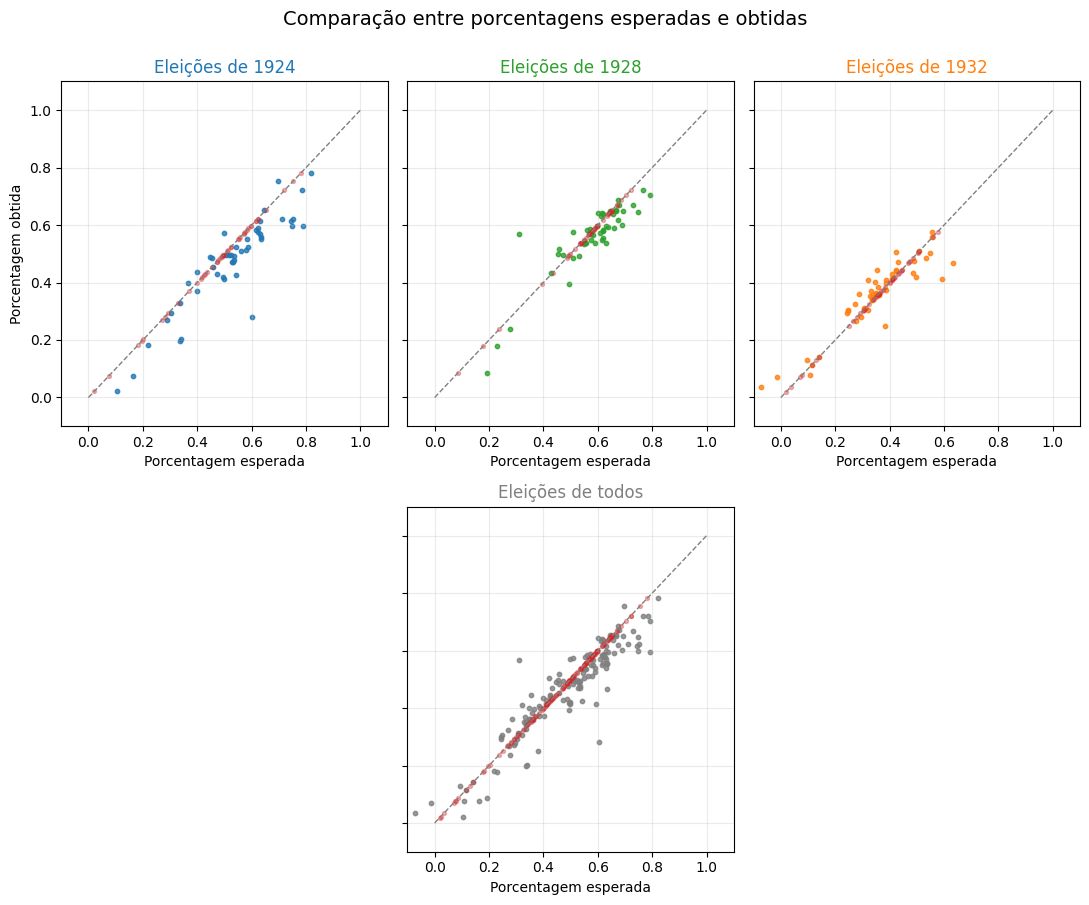

In [88]:
# Scatter plots comparativos entre porcentagem esperada e porcentagem obtida
fig, axes = plt.subplots(2, 3, figsize=(11, 9), sharey=True)
axes = axes.ravel()
colors = ["tab:blue", "tab:green", "tab:orange", "tab:cyan", "tab:gray"]

comparative_data = [
    ("1924", x_1924, y_1924),
    ("1928", x_1928, y_1928),
    ("1932", x_1932, y_1932),
    ("1936", x_1936, y_1936),
    ("todos", x, y),
]

for ax, (year, expected, actual), color in zip(axes, comparative_data, colors):
    ax.scatter(expected, actual, s=10, alpha=0.8, color=color)
    ax.scatter(actual, actual, s=8, color='tab:red', alpha=0.35, label='Real')
    # min_val = min(float(expected.min()), float(actual.min()))
    # max_val = max(float(expected.max()), float(actual.max()))
    # pad = max(0.05, (max_val - min_val) * 0.15)
    # line_min, line_max = max(0.0, min_val - pad), min(1.0, max_val + pad)
    line_min, line_max = 0, 1
    ax.plot([line_min, line_max], [line_min, line_max], linestyle="--", color="gray", linewidth=1)
    ax.set_title(f"Eleições de {year}", color=color)
    ax.set_xlabel("Porcentagem esperada")
    if ax is axes[0]:
        ax.set_ylabel("Porcentagem obtida")
    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(-0.1, 1.1)
    ax.grid(True, alpha=0.25)

axes[-1].set_visible(False)
axes[-3].set_visible(False)
fig.suptitle("Comparação entre porcentagens esperadas e obtidas", fontsize=14, y=1)
fig.tight_layout()
plt.show()

In [89]:
# --- 2. Treinamento do Modelo de Regressao com SVM ---
pipeline_svm_linear: Pipeline = Pipeline([
    ('svm', SVR(kernel='linear', C=100, gamma='scale')) # Médias: [0.8322, 0.7217]
])

# pipeline_svm_linear: Pipeline = Pipeline([
#     ('svm', SVR(kernel='rbf', C=1000, gamma=0.01)) # Médias: [0.8407, 0.7211]
# ])

# pipeline_svm_linear: Pipeline = Pipeline([
#     # ('scaler', StandardScaler()),
#     ('svm', SVR(kernel='rbf', C=100, gamma=0.01)) # Médias: [0.8463, 0.7188]
# ])

# pipeline_svm_linear: Pipeline = Pipeline([
#     ('scaler', StandardScaler()),
#     ('svm', SVR(kernel='rbf', C=1, gamma=1))
# ])

MAE do SVR linear: 0.1536
RMSE do SVR linear: 0.1708
R2 do SVR linear: -1.0876
R2 em cada fold: [0.81946236 0.18079829 0.84368244 0.47744821 0.55679469]
Media: 0.5756
Desvio-padrão: 0.2438



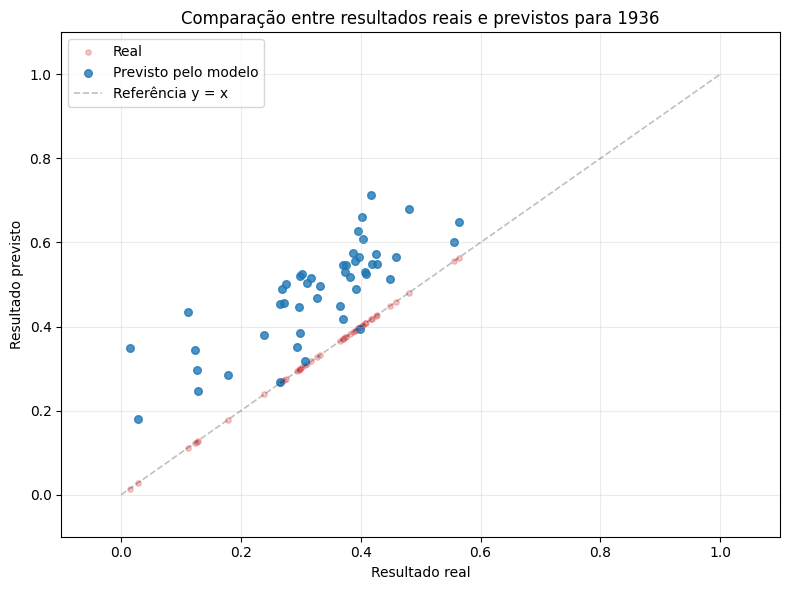

In [90]:
pipeline_svm_linear.fit(x, y)

x_1936 = x_1936.reshape(-1, 1)
# Previsão de resultados de eleições com amostras e resultados já conhecidos
y_pred: ndarray[tuple[int], dtype[np.float64]] = pipeline_svm_linear.predict(x_1936)

# Metricas apropriadas para um alvo continuo
mae_linear: float = mean_absolute_error(y_1936, y_pred)
rmse_linear: float = mean_squared_error(y_1936, y_pred) ** 0.5
r2_linear: float = r2_score(y_1936, y_pred)

# Validacao cruzada do SVR linear para analise do modelo em diferentes amostras
scores_linear: ndarray[tuple[int], dtype[np.floating]] = cross_val_score(pipeline_svm_linear, x_1936, y_1936, cv=5)

print(f"MAE do SVR linear: {mae_linear:.4f}")
print(f"RMSE do SVR linear: {rmse_linear:.4f}")
print(f"R2 do SVR linear: {r2_linear:.4f}")
print("R2 em cada fold:", scores_linear)
print(f"Media: {scores_linear.mean():.4f}")
print(f"Desvio-padrão: {scores_linear.std():.4f}\n")

# Scatter plot comparativo entre resultados reais e previstos pelo modelo para 1936
plt.figure(figsize=(8, 6))
plt.scatter(y_1936, y_1936, s=15, color='tab:red', alpha=0.25, label='Real')
plt.scatter(y_1936, y_pred, s=30, color='tab:blue', alpha=0.8, label='Previsto pelo modelo')

# min_val: float = min(float(y_1936.min()), float(y_pred.min()))
# max_val: float = max(float(y_1936.max()), float(y_pred.max()))
# margin: float = max(0.05, (max_val - min_val) * 0.12)
# line_min, line_max = max(0.0, min_val - margin), min(1.0, max_val + margin)
line_min, line_max = 0, 1
plt.plot([line_min, line_max], [line_min, line_max], linestyle='--', color='black', linewidth=1.2, label='Referência y = x', alpha=0.25)

plt.title('Comparação entre resultados reais e previstos para 1936')
plt.xlabel('Resultado real')
plt.ylabel('Resultado previsto')
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

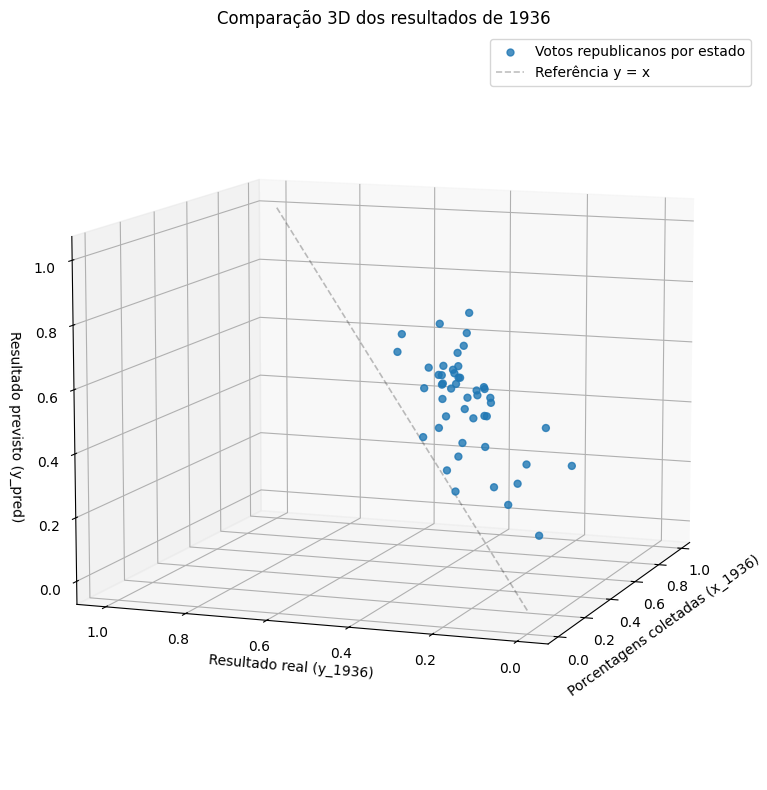

In [91]:
# Plot 3D dos valores esperados, reais e previstos
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

x_1936_3d = np.asarray(x_1936).ravel()
y_1936_3d = np.asarray(y_1936).ravel()
y_pred_3d = np.asarray(y_pred).ravel()

ax.scatter(
    x_1936_3d,
    y_1936_3d,
    y_pred_3d,
    s=25,
    alpha=0.8,
    color="tab:blue",
    label="Votos republicanos por estado",
)

plt.plot([0, 1], [0, 1], [0, 1], linestyle='--', color='black', linewidth=1.2, label='Referência y = x', alpha=0.25)

ax.view_init(elev=10, azim=200, roll=0)

ax.set_title("Comparação 3D dos resultados de 1936")
ax.set_xlabel("Porcentagens coletadas (x_1936)")
ax.set_ylabel("Resultado real (y_1936)")
ax.set_zlabel("Resultado previsto (y_pred)")
ax.grid(True, alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

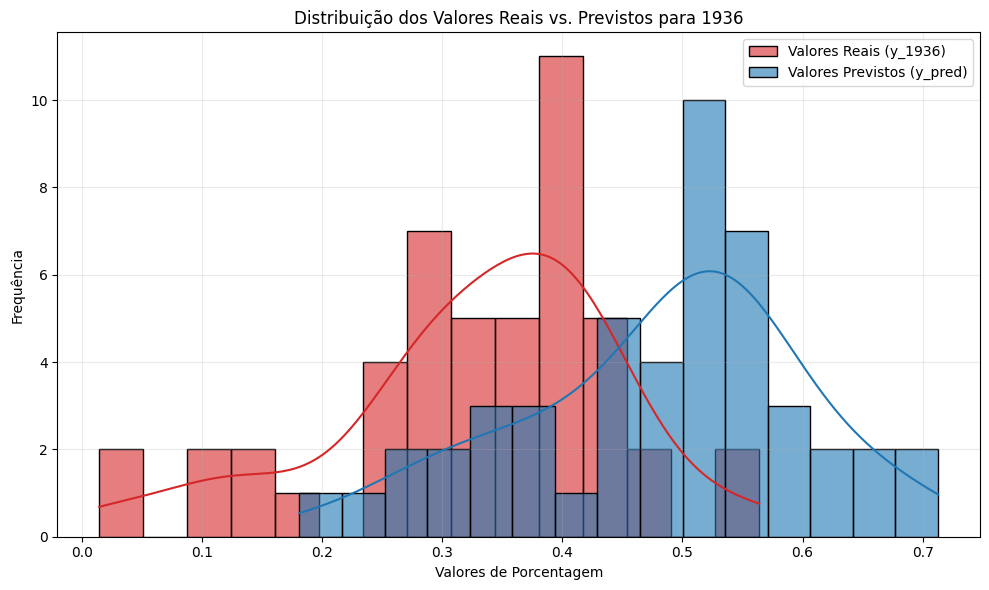

In [92]:
plt.figure(figsize=(10, 6))
sns.histplot(y_1936, color='tab:red', label='Valores Reais (y_1936)', kde=True, alpha=0.6, bins=15)
sns.histplot(y_pred, color='tab:blue', label='Valores Previstos (y_pred)', kde=True, alpha=0.6, bins=15)
plt.title('Distribuição dos Valores Reais vs. Previstos para 1936')
plt.xlabel('Valores de Porcentagem')
plt.ylabel('Frequência')
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

In [93]:
correlation_1936 = np.corrcoef(y_1936, y_pred)[0, 1]
print(f"Correlação entre valores reais e previstos para 1936: {correlation_1936:.4f}")

Correlação entre valores reais e previstos para 1936: 0.7954


In [94]:
df_results = DataFrame(
    [
      StatesEnum._member_names_,
      ['Republicano' if rep > 0.50 else 'Democrata' for rep in y_pred],
      ['Republicano' if rep > 0.50 else 'Democrata' for rep in votes1936.get_results()[votes1936.get_results().columns[2]] > 50],
    ]).transpose()

df_results['correct'] = df_results.iloc[:, 1].eq(df_results.iloc[:, 2])

print(
  df_results['correct'].value_counts(),
)

df_results

correct
False    25
True     23
Name: count, dtype: int64


,0,1,2,correct
0,ALABAMA,Democrata,Republicano,False
1,ARIZONA,Democrata,Republicano,False
2,ARKANSAS,Democrata,Republicano,False
3,CALIFORNIA,Republicano,Republicano,True
4,COLORADO,Republicano,Republicano,True
5,CONNECTICUT,Republicano,Republicano,True
6,DELAWARE,Republicano,Republicano,True
7,FLORIDA,Democrata,Republicano,False
8,GEORGIA,Democrata,Republicano,False
9,IDAHO,Democrata,Republicano,False


* **Consolidação e Rotulagem do Dataset Histórico (1924–1932):** Concatena os percentuais de intenção de voto republicano coletados nas pesquisas do *Literary Digest* (`collected_percent`) com os resultados oficiais das urnas (`actual_percent`) ao longo de três eleições (1924, 1928 e 1932), identificando o partido vencedor em cada estado (`Republican` ou `Democrat`) para compor o rótulo de supervisão (`y`).
* **Divisão Estratificada de Dados (`train_test_split`):** Separa o conjunto de 144 observações estaduais em amostras de treino (80%) e teste (20%), aplicando estratificação por classe (`stratify=y`) e fixando a semente aleatória (`seed(42)`) para assegurar a reprodutibilidade dos experimentos.
* **Pipeline de Aprendizado de Máquina (`StandardScaler` + `SVC` Linear):** Estrutura um `Pipeline` contendo a padronização z-score dos atributos e um classificador Support Vector Machine (`SVC`) com kernel linear (`kernel='linear'`, `C=1`), projetado para encontrar o hiperplano ótimo de separação de classes.
* **Avaliação Preditiva e Matriz de Confusão:** Aplica o modelo treinado na base de teste para calcular a acurácia (`accuracy_score`), gerar o relatório de classificação (`classification_report` com *precision*, *recall* e *F1-score*) e plotar a matriz de confusão (`ConfusionMatrixDisplay`) para visualizar os acertos e erros de classificação do modelo.
* **Validação Cruzada K-Fold (`cross_val_score`):** Submete o pipeline do SVM linear a uma validação cruzada com 5 dobras (`cv=5`) para mensurar a estabilidade, a média de acurácia e o desvio-padrão do classificador em diferentes partições dos dados históricos.